# Residual-gas background vs photon energy

Run 58890 is the residual-gas scan used as the photon-energy-dependent background for the config-1 glycine scans.

This notebook starts from the shot-resolved static-XAS file written by `compute_static_xas_cfg1.py`. The energy sections have already been detected from the local-DAQ train-ID starts, so the analysis here focuses on:

- averaging eTOF and iTOF spectra per photon energy,
- visualising the background as a 2D energy x TOF map,
- quantifying how the background intensity and shape change with photon energy,
- creating a per-energy background table that can be used for glycine subtraction,
- optionally loading a glycine signal map and plotting signal, background, and signal minus background.

In [101]:
import os, sys


from pathlib import Path

os.environ["FLASH_ENV"] = "remote"

In [102]:
import sys
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

%matplotlib inline

# Locate repo root and put analysis/scripts on the import path.
cwd = Path.cwd().resolve()
repo_root = Path("/home/mmanresa/glycine26/")

# 2. Safety check to make sure the folder structure is what we expect
scripts_dir = repo_root / "analysis" / "scripts"
if not scripts_dir.exists():
    raise RuntimeError(f"Could not find scripts folder at: {scripts_dir}")

# 3. Add it to Python's path
sys.path.insert(0, str(scripts_dir))

import config as path_config  # noqa: E402
import config
from compute_aggregates import load_aggregates  # noqa: E402

## Inputs (old, before doing aggregates)

`BACKGROUND_STATIC_H5` should already exist after running:

```bash
FLASH_ENV=remote python analysis/scripts/compute_static_xas_cfg1.py \
  analysis/configs/tof_static/background_run58890.py
```

For the subtraction plots, use either:

- `SIGNAL_STATIC_H5`: a compatible glycine static-XAS output, or
- `SIGNAL_AGG_FILES`: the aggregate files used by `cfg1_etof_vs_energy.ipynb`, one file per photon energy.

Leave both as `None` while developing the background-only part.

In [103]:
RUN_NO = 58890

BACKGROUND_STATIC_H5 = (
    Path(path_config.COMBINED_DIR).parent
    / "xas_static"
    / f"run{RUN_NO}_cfg1_static_xas.h5"
)

# Option A: point this at a glycine static-XAS file with datasets matching
# compute_static_xas_cfg1.py output.
SIGNAL_STATIC_H5 = None
# Example:
# SIGNAL_STATIC_H5 = Path(path_config.COMBINED_DIR).parent / "xas_static" / "runXXXXX_cfg1_static_xas.h5"

# Option B: use config-1 aggregate files, as in cfg1_etof_vs_energy.ipynb.
# Each tuple is (path, photon_energy_eV). If SIGNAL_GMD_BIN is None, the
# notebook averages D/G across GMD bins weighted by n_per_bin.
SIGNAL_AGG_FILES = None
# Example:
# SIGNAL_AGG_FILES = [
#     (Path(path_config.COMBINED_DIR) / "glycine_WL_scan_271.0eV_aggregates.h5", 271.0),
#     (Path(path_config.COMBINED_DIR) / "glycine_WL_scan_271.5eV_aggregates.h5", 271.5),
# ]
SIGNAL_GMD_BIN = None

# TOF histogram edges. Use np.arange for a fixed bin width.
# The calibration notebook uses 1-unit eTOF bins over [0, 5000].
# Do not write np.linspace(0, 5000, 1): that creates only one edge,
# i.e. zero bins.
ETOF_BIN_WIDTH = 1.0
ETOF_BIN_EDGES = np.arange(0.0, 5000.0 + ETOF_BIN_WIDTH, ETOF_BIN_WIDTH)

# Ions are usually much later; keep a wider range by default.
ITOF_BIN_WIDTH = 20.0
ITOF_BIN_EDGES = np.arange(0.0, 40000.0 + ITOF_BIN_WIDTH, ITOF_BIN_WIDTH)

# Duplicate nominal energies: "keep_last" keeps the later repeat,
# "merge" averages repeats weighted by summed GMD, "keep_all" keeps sections.
DUPLICATE_ENERGY_POLICY = "keep_last"

# Optional scale factor for subtraction. Keep at 1.0 for GMD-normalised maps.
BACKGROUND_SCALE = 1.0

# Display ranges. Use (None, None) for full range.
ETOF_RANGE = (None, None)
ITOF_RANGE = (None, None)

print("background:", BACKGROUND_STATIC_H5)
print("signal static:", SIGNAL_STATIC_H5)
print("signal aggs  :", SIGNAL_AGG_FILES)

background: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/xas_static/run58890_cfg1_static_xas.h5
signal static: None
signal aggs  : None


## Helpers

In [104]:
def load_static_xas(path):
    """Load a compute_static_xas_cfg1.py output file."""
    path = Path(path)
    with h5py.File(path, "r") as f:
        out = {
            "path": path,
            "tofs_e": f["tofs_e"][...],
            "tofs_i": f["tofs_i"][...],
            "gmd": f["gmd"][...],
            "n_shots": f["n_shots"][...].astype(np.int64),
            "energies": f["nominal_energies"][...].astype(np.float64),
            "attrs": dict(f.attrs),
        }
    return out


def spectra_per_energy(tofs, gmd, n_shots, edges):
    """Histogram TOF hits per energy section and normalise by summed GMD."""
    n_energy = tofs.shape[0]
    n_bins = len(edges) - 1
    spec = np.full((n_energy, n_bins), np.nan, dtype=np.float64)
    sum_gmd = np.zeros(n_energy, dtype=np.float64)
    valid_shots = np.zeros(n_energy, dtype=np.int64)
    hit_counts = np.zeros(n_energy, dtype=np.int64)

    for i in range(n_energy):
        n = int(n_shots[i])
        if n <= 0:
            continue

        g = gmd[i, :n]
        ok = np.isfinite(g)
        if not ok.any():
            continue

        hits = tofs[i, :n][ok].ravel()
        hits = hits[hits > 0]
        sum_gmd[i] = float(np.nansum(g[ok]))
        valid_shots[i] = int(ok.sum())
        hit_counts[i] = int(hits.size)

        if hits.size == 0 or sum_gmd[i] <= 0:
            continue

        hist, _ = np.histogram(hits, bins=edges)
        spec[i] = hist / sum_gmd[i]

    return spec, sum_gmd, valid_shots, hit_counts


def merge_repeated_energies(spec, energies, weights=None):
    """Weighted-average spectra for repeated nominal energies."""
    energies = np.asarray(energies, dtype=np.float64)
    unique = np.array(sorted(np.unique(energies)))
    merged = np.full((unique.size, spec.shape[1]), np.nan, dtype=np.float64)
    if weights is None:
        weights = np.ones(energies.size, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)

    for i, e in enumerate(unique):
        idx = np.where(energies == e)[0]
        rows = spec[idx]
        w = weights[idx]
        valid = np.isfinite(rows).any(axis=1) & np.isfinite(w) & (w > 0)
        if not valid.any():
            continue
        merged[i] = np.average(rows[valid], axis=0, weights=w[valid])
    return unique, merged


def resolve_duplicate_energies(spec, energies, *, policy="keep_last", weights=None):
    """Handle repeated nominal energies after section-wise spectra are made."""
    energies = np.asarray(energies, dtype=np.float64)
    if policy == "keep_all":
        return energies, spec
    if policy == "merge":
        return merge_repeated_energies(spec, energies, weights=weights)
    if policy != "keep_last":
        raise ValueError("DUPLICATE_ENERGY_POLICY must be 'keep_last', 'merge', or 'keep_all'")

    keep = []
    for e in sorted(np.unique(energies)):
        idx = np.where(energies == e)[0]
        keep.append(idx[-1])
    keep = np.array(keep, dtype=np.int64)
    return energies[keep], spec[keep]


def half_step_edges(x):
    x = np.asarray(x, dtype=np.float64)
    if x.size == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5])
    mid = 0.5 * (x[:-1] + x[1:])
    return np.concatenate([[2 * x[0] - mid[0]], mid, [2 * x[-1] - mid[-1]]])


def plot_map(spec, tof_edges, energies, *, title, clabel, tof_range=(None, None), cmap="viridis"):
    e_edges = half_step_edges(energies)
    finite = spec[np.isfinite(spec)]
    vmin = float(np.nanpercentile(finite, 1)) if finite.size else 0.0
    vmax = float(np.nanpercentile(finite, 99.5)) if finite.size else 1.0
    fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
    im = ax.pcolormesh(tof_edges, e_edges, spec, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, label=clabel)
    ax.set_xlabel("TOF (100 ps ticks)")
    ax.set_ylabel("nominal photon energy (eV)")
    ax.set_title(title)
    if tof_range[0] is not None or tof_range[1] is not None:
        ax.set_xlim(tof_range)
    return fig, ax


def plot_diff_map(diff, tof_edges, energies, *, title, clabel, tof_range=(None, None)):
    e_edges = half_step_edges(energies)
    finite = diff[np.isfinite(diff)]
    lim = float(np.nanpercentile(np.abs(finite), 99.0)) if finite.size else 1.0
    if not np.isfinite(lim) or lim <= 0:
        lim = 1.0
    fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
    im = ax.pcolormesh(tof_edges, e_edges, diff, shading="auto", cmap="RdBu_r", norm=norm)
    fig.colorbar(im, ax=ax, label=clabel)
    ax.set_xlabel("TOF (100 ps ticks)")
    ax.set_ylabel("nominal photon energy (eV)")
    ax.set_title(title)
    if tof_range[0] is not None or tof_range[1] is not None:
        ax.set_xlim(tof_range)
    return fig, ax

In [105]:
def load_signal_aggregate_map(files, *, gmd_bin=None):
    """Load config-1 spectral aggregates into an energy x eTOF map."""
    files = sorted([(Path(p), float(e)) for p, e in files], key=lambda pe: pe[1])
    energies = np.array([e for _, e in files], dtype=np.float64)
    stack = []
    tof_edges = None
    shot_counts = []

    for path, energy in files:
        agg = load_aggregates(path)
        if agg.config != 1:
            raise ValueError(f"{path.name}: expected config 1, found config {agg.config}")
        if agg.mode != "spectral":
            raise ValueError(f"{path.name}: expected spectral aggregate, found {agg.mode!r}")
        if tof_edges is None:
            tof_edges = agg.tof_edges
        elif not np.array_equal(tof_edges, agg.tof_edges):
            raise ValueError(f"{path.name}: eTOF edges do not match previous aggregate files")

        with np.errstate(invalid="ignore", divide="ignore"):
            per_gmd = agg.D / agg.G[:, None]

        if gmd_bin is None:
            weights = np.asarray(agg.n_per_bin, dtype=np.float64)
            valid = np.isfinite(per_gmd).any(axis=1) & (weights > 0)
            if not valid.any():
                spec = np.full(per_gmd.shape[1], np.nan)
            else:
                spec = np.average(per_gmd[valid], axis=0, weights=weights[valid])
        else:
            spec = per_gmd[int(gmd_bin)]

        stack.append(spec)
        shot_counts.append(int(np.sum(agg.n_per_bin)))
        print(f"{energy:7.2f} eV  {path.name}  shots={shot_counts[-1]}")

    return {
        "energies": energies,
        "tof_edges": tof_edges,
        "spec_e": np.vstack(stack),
        "shot_counts": np.array(shot_counts, dtype=np.int64),
    }


def rebin_background_if_needed(bg_source, source_edges, target_edges):
    """Return background on target edges; currently requires identical bins."""
    if not np.array_equal(source_edges, target_edges):
        raise ValueError(
            "background and signal TOF edges differ. Re-run this notebook with "
            "ETOF_BIN_EDGES matching the aggregate TOF edges, or add explicit rebinning."
        )
    return bg_source

## Load and average run 58890

In [106]:
bg = load_static_xas(BACKGROUND_STATIC_H5)

bg_spec_e_raw, bg_sum_gmd, bg_valid_shots, bg_hits_e = spectra_per_energy(
    bg["tofs_e"], bg["gmd"], bg["n_shots"], ETOF_BIN_EDGES
)
bg_spec_i_raw, _, _, bg_hits_i = spectra_per_energy(
    bg["tofs_i"], bg["gmd"], bg["n_shots"], ITOF_BIN_EDGES
)

bg_energies, bg_spec_e = resolve_duplicate_energies(
    bg_spec_e_raw, bg["energies"], policy=DUPLICATE_ENERGY_POLICY, weights=bg_sum_gmd
)
_, bg_spec_i = resolve_duplicate_energies(
    bg_spec_i_raw, bg["energies"], policy=DUPLICATE_ENERGY_POLICY, weights=bg_sum_gmd
)

print(f"loaded {bg['path'].name}")
print(f"sections              : {bg['energies'].size}")
print(f"plotted energies       : {bg_energies.size} ({DUPLICATE_ENERGY_POLICY})")
print(f"shots total            : {int(bg['n_shots'].sum())}")
print(f"signal bunch range attr: {tuple(bg['attrs'].get('signal_bunch_range', []))}")
print(f"section source attr    : {bg['attrs'].get('section_source', 'not recorded')}")

for i, e in enumerate(bg["energies"]):
    print(
        f"section {i:2d}  E={e:6.2f} eV  "
        f"shots={int(bg['n_shots'][i]):7d}  "
        f"sumGMD={bg_sum_gmd[i]:10.3g}  "
        f"eHits={bg_hits_e[i]:8d}  iHits={bg_hits_i[i]:8d}"
    )

loaded run58890_cfg1_static_xas.h5
sections              : 11
plotted energies       : 9 (keep_last)
shots total            : 742920
signal bunch range attr: (10, 40)
section source attr    : tid_starts
section  0  E=271.00 eV  shots=  56790  sumGMD=  2.35e+05  eHits=   18452  iHits=   36187
section  1  E=271.50 eV  shots=  54750  sumGMD=  2.14e+05  eHits=   13198  iHits=   28834
section  2  E=272.00 eV  shots=  55110  sumGMD=  1.79e+05  eHits=   11043  iHits=   24006
section  3  E=272.50 eV  shots=  58200  sumGMD=   1.9e+05  eHits=   12109  iHits=   25505
section  4  E=273.00 eV  shots=  74880  sumGMD=  1.81e+05  eHits=    9880  iHits=   19092
section  5  E=273.50 eV  shots=  73200  sumGMD=  3.97e+05  eHits=   26620  iHits=   45143
section  6  E=274.00 eV  shots=  72690  sumGMD=  3.92e+05  eHits=   22100  iHits=   41909
section  7  E=274.50 eV  shots=  75300  sumGMD=  3.96e+05  eHits=   20012  iHits=   38207
section  8  E=275.00 eV  shots=  73380  sumGMD=  3.72e+05  eHits=   15864  iH

## Background 2D maps

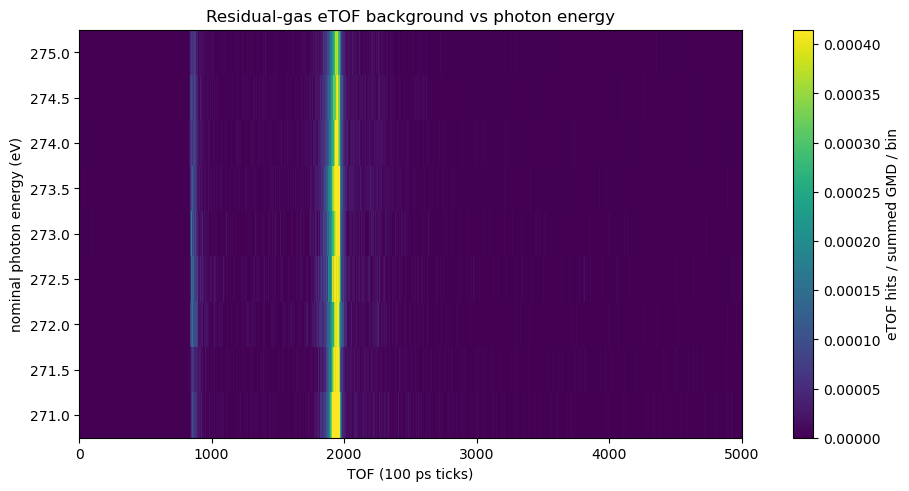

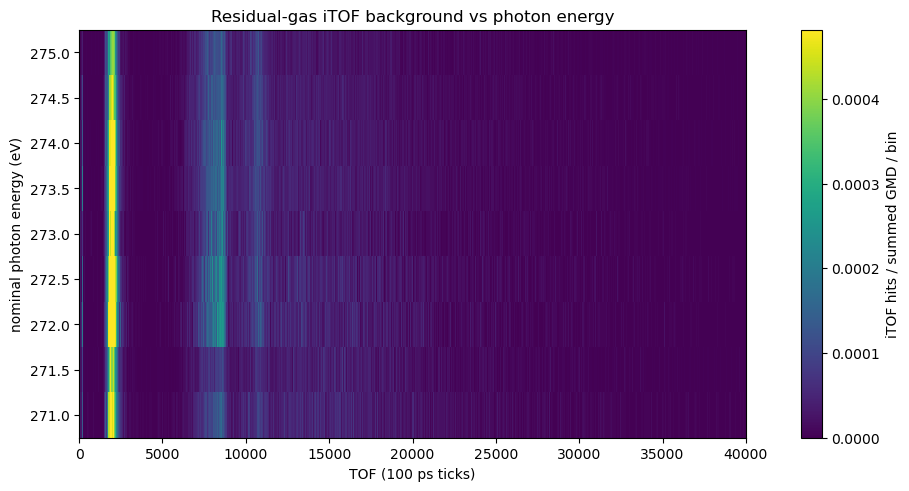

In [107]:
plot_map(
    bg_spec_e,
    ETOF_BIN_EDGES,
    bg_energies,
    title="Residual-gas eTOF background vs photon energy",
    clabel="eTOF hits / summed GMD / bin",
    tof_range=ETOF_RANGE,
)
plt.show()

plot_map(
    bg_spec_i,
    ITOF_BIN_EDGES,
    bg_energies,
    title="Residual-gas iTOF background vs photon energy",
    clabel="iTOF hits / summed GMD / bin",
    tof_range=ITOF_RANGE,
)
plt.show()

## Individual aggregates

In [108]:
# --- Load residual-gas background aggregates -------------------------

import re
from compute_aggregates import load_aggregates

BACKGROUND_AGG_DIR = config.COMBINED_DIR / "background_run58890_per_energy"
BACKGROUND_GLOB = "background_*eV_run58890_aggregates_etof1.h5"
BACKGROUND_ENERGY_RE = re.compile(
    r"^background_(\d+(?:\.\d+)?)eV_run58890_aggregates_etof1\.h5$"
)

MAX_ENERGY = None  # or 279.5 if you want to restrict

def _energy_from_background_agg_name(p):
    m = BACKGROUND_ENERGY_RE.fullmatch(Path(p).name)
    if not m:
        raise ValueError(f"could not parse energy from {p}")
    return float(m.group(1))

bg_agg_files = []
for p in sorted(Path(BACKGROUND_AGG_DIR).glob(BACKGROUND_GLOB)):
    e = _energy_from_background_agg_name(p)
    if MAX_ENERGY is None or e <= MAX_ENERGY:
        bg_agg_files.append((p, e))

bg_agg_files = sorted(bg_agg_files, key=lambda pe: pe[1])

print(f"{len(bg_agg_files)} background aggregate files:")
for p, e in bg_agg_files:
    print(f"  {e:7.2f} eV  {p.name}")

tof_to_ke = KE_from_TOF

9 background aggregate files:
   271.00 eV  background_271.0eV_run58890_aggregates_etof1.h5
   271.50 eV  background_271.5eV_run58890_aggregates_etof1.h5
   272.00 eV  background_272.0eV_run58890_aggregates_etof1.h5
   272.50 eV  background_272.5eV_run58890_aggregates_etof1.h5
   273.00 eV  background_273.0eV_run58890_aggregates_etof1.h5
   273.50 eV  background_273.5eV_run58890_aggregates_etof1.h5
   274.00 eV  background_274.0eV_run58890_aggregates_etof1.h5
   274.50 eV  background_274.5eV_run58890_aggregates_etof1.h5
   275.00 eV  background_275.0eV_run58890_aggregates_etof1.h5


In [109]:
# --- Stack aggregate background maps: energy x GMD bin x eTOF --------

bg_agg_energies = np.array([e for _, e in bg_agg_files], dtype=float)

bg_agg_stack = None
bg_agg_n_shots = None
bg_agg_tof_edges = None
bg_agg_gmd_edges = None

for k, (path, e) in enumerate(bg_agg_files):
    agg = load_aggregates(path)

    if agg.config != 1:
        raise ValueError(f"{path.name}: expected config 1, got {agg.config}")
    if agg.mode != "spectral":
        raise ValueError(f"{path.name}: expected spectral mode, got {agg.mode!r}")

    if bg_agg_tof_edges is None:
        bg_agg_tof_edges = agg.tof_edges
        bg_agg_gmd_edges = agg.gmd_edges

        n_E = len(bg_agg_files)
        n_gmd = agg.n_gmd_bins
        n_tof = agg.n_tof

        bg_agg_stack = np.full((n_E, n_gmd, n_tof), np.nan)
        bg_agg_n_shots = np.zeros((n_E, n_gmd), dtype=int)
    else:
        if not np.array_equal(agg.tof_edges, bg_agg_tof_edges):
            raise ValueError(f"{path.name}: tof_edges mismatch")
        if not np.array_equal(agg.gmd_edges, bg_agg_gmd_edges):
            raise ValueError(f"{path.name}: gmd_edges mismatch")

    with np.errstate(invalid="ignore", divide="ignore"):
        bg_agg_stack[k] = agg.D / agg.G[:, None]

    bg_agg_n_shots[k] = agg.n_per_bin

print("background aggregate stack:", bg_agg_stack.shape)
print("energies:", bg_agg_energies)
print("GMD edges:", bg_agg_gmd_edges)
print("TOF:", bg_agg_tof_edges[0], bg_agg_tof_edges[-1], len(bg_agg_tof_edges) - 1)

background aggregate stack: (9, 4, 5000)
energies: [271.  271.5 272.  272.5 273.  273.5 274.  274.5 275. ]
GMD edges: [ 0.  3.  6. 12. 24.]
TOF: 0.0 5000.0 5000


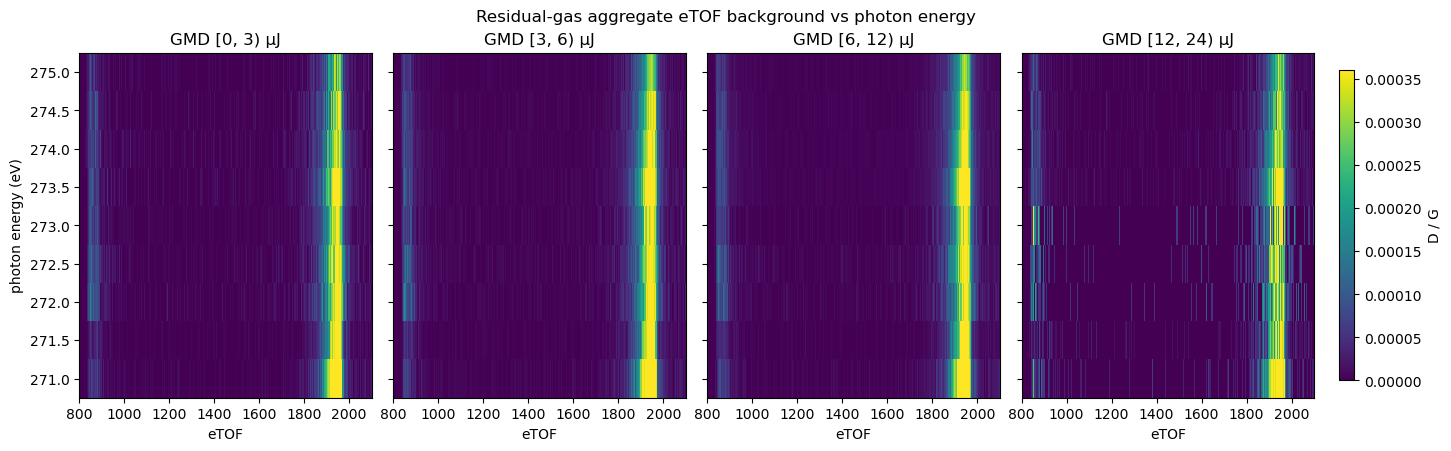

In [110]:
# --- Plot aggregate background 2D maps -------------------------------

def _energy_edges(e):
    e = np.asarray(e, dtype=float)
    if len(e) == 1:
        return np.array([e[0] - 0.25, e[0] + 0.25])
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])

e_edges = _energy_edges(bg_agg_energies)

finite = bg_agg_stack[np.isfinite(bg_agg_stack)]

VMIN = float(np.nanpercentile(finite, 1))
VMAX = float(np.nanpercentile(finite, 99.5))


TOF_RANGE = (800, 1100)

fig, axes = plt.subplots(
    1, len(bg_agg_gmd_edges) - 1,
    figsize=(3.6 * (len(bg_agg_gmd_edges) - 1), 4.4),
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for g, ax in enumerate(axes):
    pcm = ax.pcolormesh(
        bg_agg_tof_edges,
        e_edges,
        bg_agg_stack[:, g, :],
        cmap="viridis",
        vmin=VMIN,
        vmax=VMAX,
        shading="auto",
    )

    ax.set_title(f"GMD [{bg_agg_gmd_edges[g]:.2g}, {bg_agg_gmd_edges[g+1]:.2g}) µJ")
    ax.set_xlabel("eTOF")
    ax.set_xlim(*TOF_RANGE)
    ax.set_xlim(800,2100)   #Bright feature at around 2000

axes[0].set_ylabel("photon energy (eV)")
cbar = fig.colorbar(pcm, ax=axes, location="right", shrink=0.9, pad=0.02)
cbar.set_label("D / G")
fig.suptitle("Residual-gas aggregate eTOF background vs photon energy")
plt.show()

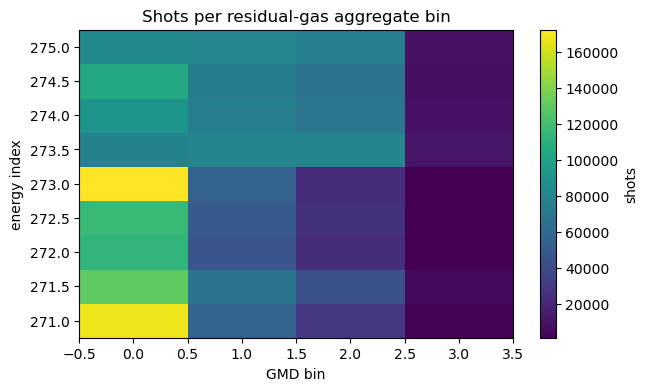

In [111]:
plt.figure(figsize=(7, 4))
plt.imshow(bg_agg_n_shots, aspect="auto", origin="lower")
plt.colorbar(label="shots")
plt.xlabel("GMD bin")
plt.ylabel("energy index")
plt.yticks(np.arange(len(bg_agg_energies)), [f"{e:.1f}" for e in bg_agg_energies])
plt.title("Shots per residual-gas aggregate bin")
plt.show()

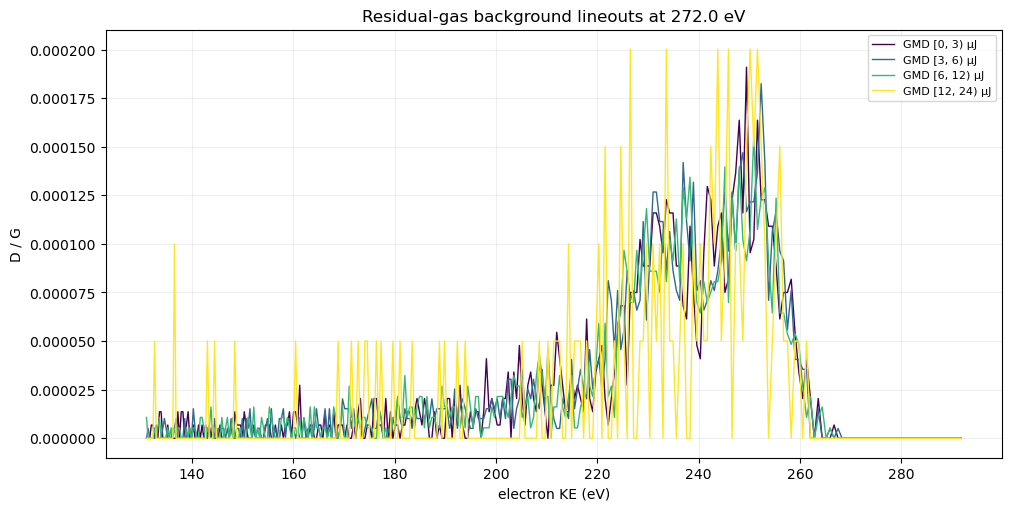

In [112]:
# --- Background-only lineouts: each GMD bin for one photon energy -----

BACKGROUND_ENERGY_TO_PLOT = 272.0
TOF_LINEOUT_RANGE = (800, 1100)
USE_KE_AXIS = True

idx = np.where(np.isclose(bg_agg_energies, BACKGROUND_ENERGY_TO_PLOT))[0]
if len(idx) == 0:
    raise ValueError(
        f"{BACKGROUND_ENERGY_TO_PLOT:.1f} eV not found in bg_agg_energies: "
        f"{bg_agg_energies}"
    )

i = int(idx[0])

tof_cent = 0.5 * (bg_agg_tof_edges[:-1] + bg_agg_tof_edges[1:])
tof_mask = np.ones_like(tof_cent, dtype=bool)
if TOF_LINEOUT_RANGE[0] is not None:
    tof_mask &= tof_cent >= TOF_LINEOUT_RANGE[0]
if TOF_LINEOUT_RANGE[1] is not None:
    tof_mask &= tof_cent <= TOF_LINEOUT_RANGE[1]

if USE_KE_AXIS:
    x = tof_to_ke(tof_cent[tof_mask])
    good = np.isfinite(x)
    order = np.argsort(x[good])
    x_plot = x[good][order]
    xlabel = "electron KE (eV)"
else:
    good = np.ones(np.count_nonzero(tof_mask), dtype=bool)
    order = np.arange(np.count_nonzero(tof_mask))
    x_plot = tof_cent[tof_mask]
    xlabel = "eTOF"

cmap = plt.get_cmap("viridis")
n_gmd = len(bg_agg_gmd_edges) - 1

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

for g in range(n_gmd):
    y = bg_agg_stack[i, g, tof_mask]
    y = y[good][order]

    ax.plot(
        x_plot,
        y,
        lw=1.0,
        color=cmap(g / max(n_gmd - 1, 1)),
        label=f"GMD [{bg_agg_gmd_edges[g]:.2g}, {bg_agg_gmd_edges[g+1]:.2g}) µJ",
    )

ax.set_xlabel(xlabel)
ax.set_ylabel("D / G")
ax.set_title(f"Residual-gas background lineouts at {bg_agg_energies[i]:.1f} eV")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

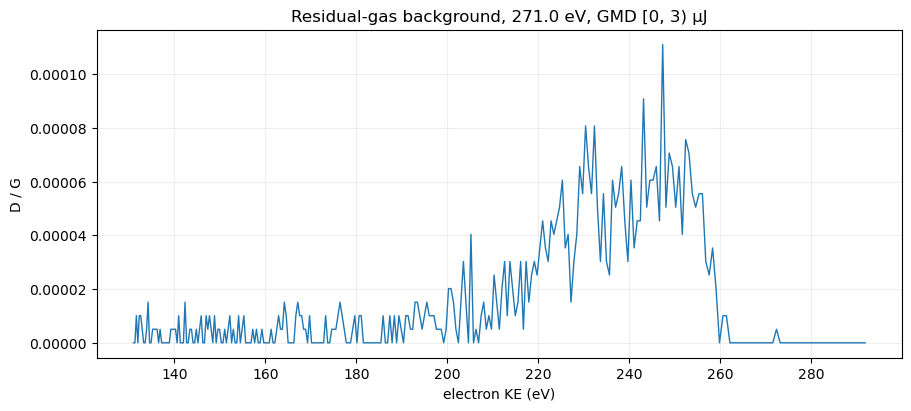

Plotted background energy: 271.00 eV
GMD bin: [0.0, 3.0) µJ
max D/G in plotted range: 0.000110981


In [113]:
# --- Background lineout: first GMD bin, lowest photon energy ----------

GMD_BIN = 0
TOF_LINEOUT_RANGE = (800, 1100)
USE_KE_AXIS = True

# Lowest available background photon energy
i = int(np.nanargmin(bg_agg_energies))
e = bg_agg_energies[i]

tof_cent = 0.5 * (bg_agg_tof_edges[:-1] + bg_agg_tof_edges[1:])

tof_mask = np.ones_like(tof_cent, dtype=bool)
if TOF_LINEOUT_RANGE[0] is not None:
    tof_mask &= tof_cent >= TOF_LINEOUT_RANGE[0]
if TOF_LINEOUT_RANGE[1] is not None:
    tof_mask &= tof_cent <= TOF_LINEOUT_RANGE[1]

y = bg_agg_stack[i, GMD_BIN, tof_mask]

if USE_KE_AXIS:
    x = tof_to_ke(tof_cent[tof_mask])
    good = np.isfinite(x)
    x = x[good]
    y = y[good]

    order = np.argsort(x)
    x = x[order]
    y = y[order]
    xlabel = "electron KE (eV)"
else:
    x = tof_cent[tof_mask]
    xlabel = "eTOF"

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(x, y, lw=1.0)

ax.set_xlabel(xlabel)
ax.set_ylabel("D / G")
ax.set_title(
    f"Residual-gas background, {e:.1f} eV, "
    f"GMD [{bg_agg_gmd_edges[GMD_BIN]:.2g}, {bg_agg_gmd_edges[GMD_BIN+1]:.2g}) µJ"
)
ax.grid(alpha=0.2)

plt.show()

print(f"Plotted background energy: {e:.2f} eV")
print(f"GMD bin: [{bg_agg_gmd_edges[GMD_BIN]}, {bg_agg_gmd_edges[GMD_BIN+1]}) µJ")
print(f"max D/G in plotted range: {np.nanmax(y):.6g}")

## Load the signal runs

In [114]:
# --- Option A: explicit list (path, energy_eV) -----------------------
FILES = None  # e.g. [("runXXX_aggregates.h5", 290.0), ...]

# --- Option B: glob a directory and parse eV from filename ----------
AGG_DIR    = config.COMBINED_DIR
GLOB = "glycine_WL_scan_*eV_aggregates_etof1.h5"

ENERGY_RE = re.compile(
    r"^glycine_WL_scan_(\d+(?:\.\d+)?)eV_aggregates_etof1$"
)

MAX_ENERGY = 279.5

# --- Display / cosmetics -------------------------------------------
TOF_RANGE  = (None, None)   # plot x-limits in TOF units; (None, None) = full
VMIN, VMAX = None, None     # shared colour scale for plot 1; None = auto
DIFF_SYM   = True           # symmetric diverging colormap for plot 2

# --- Discover files ------------------------------------------------
def _energy_from_name(p):
    m = ENERGY_RE.search(Path(p).stem)
    if not m:
        raise ValueError(
            f"could not parse photon energy (looked for '<num>eV') from {p}"
        )
    return float(m.group(1))

if FILES is None:
    paths = sorted(Path(AGG_DIR).glob(GLOB))
    if not paths:
        raise FileNotFoundError(f"no files match {AGG_DIR}/{GLOB}")
    FILES = [(p, _energy_from_name(p)) for p in paths]

FILES = [(p, e) for p, e in FILES if e <= MAX_ENERGY]


def _is_decimal_zero_energy_file(p):
    return re.search(r"_\d+\.0eV_aggregates_etof1\.h5$", Path(p).name) is not None

# For repeated nominal energies, prefer the file written as "279.0eV"
# over the bare "279eV".
dedup = {}
for p, e in FILES:
    old = dedup.get(e)
    if old is None:
        dedup[e] = (p, e)
    elif _is_decimal_zero_energy_file(p):
        dedup[e] = (p, e)

FILES = sorted(dedup.values(), key=lambda pe: pe[1])

print(f"{len(FILES)} aggregate files:")
for p, e in FILES:
    print(f"  {e:>8.2f} eV  {Path(p).name}")

20 aggregate files:
    270.00 eV  glycine_WL_scan_270.0eV_aggregates_etof1.h5
    270.50 eV  glycine_WL_scan_270.5eV_aggregates_etof1.h5
    271.00 eV  glycine_WL_scan_271.0eV_aggregates_etof1.h5
    271.50 eV  glycine_WL_scan_271.5eV_aggregates_etof1.h5
    272.00 eV  glycine_WL_scan_272.0eV_aggregates_etof1.h5
    272.50 eV  glycine_WL_scan_272.5eV_aggregates_etof1.h5
    273.00 eV  glycine_WL_scan_273.0eV_aggregates_etof1.h5
    273.50 eV  glycine_WL_scan_273.5eV_aggregates_etof1.h5
    274.00 eV  glycine_WL_scan_274.0eV_aggregates_etof1.h5
    274.50 eV  glycine_WL_scan_274.5eV_aggregates_etof1.h5
    275.00 eV  glycine_WL_scan_275.0eV_aggregates_etof1.h5
    275.50 eV  glycine_WL_scan_275.5eV_aggregates_etof1.h5
    276.00 eV  glycine_WL_scan_276.0eV_aggregates_etof1.h5
    276.50 eV  glycine_WL_scan_276.5eV_aggregates_etof1.h5
    277.00 eV  glycine_WL_scan_277.0eV_aggregates_etof1.h5
    277.50 eV  glycine_WL_scan_277.5eV_aggregates_etof1.h5
    278.00 eV  glycine_WL_scan_278.0

In [148]:
energies = np.array([e for _, e in FILES], dtype=np.float64)

stack = None        # (n_E, n_gmd, n_tof) normalised D/G
n_shots = None      # (n_E, n_gmd) shot count per bin
tof_edges = None
gmd_edges = None

for k, (path, e) in enumerate(FILES):
    agg = load_aggregates(path)
    if agg.config != 1:
        raise ValueError(
            f"{Path(path).name}: config={agg.config}, expected 1"
        )
    if agg.mode != "spectral":
        raise ValueError(
            f"{Path(path).name}: mode={agg.mode!r}, expected 'spectral'"
        )
    if tof_edges is None:
        tof_edges = agg.tof_edges
        gmd_edges = agg.gmd_edges
        n_E   = len(FILES)
        n_gmd = agg.n_gmd_bins
        n_tof = agg.n_tof
        stack   = np.full((n_E, n_gmd, n_tof), np.nan, dtype=np.float64)
        n_shots = np.zeros((n_E, n_gmd), dtype=np.int64)
    else:
        if not np.array_equal(agg.tof_edges, tof_edges):
            raise ValueError(
                f"{Path(path).name}: tof_edges mismatch"
            )
        if not np.array_equal(agg.gmd_edges, gmd_edges):
            raise ValueError(
                f"{Path(path).name}: gmd_edges mismatch"
            )

    # D / G per GMD bin; broadcast G along the TOF axis.
    with np.errstate(invalid="ignore", divide="ignore"):
        stack[k] = agg.D / agg.G[:, None]
    n_shots[k] = agg.n_per_bin

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
gmd_cent = 0.5 * (gmd_edges[:-1] + gmd_edges[1:])

print(f"stack shape  : {stack.shape}  (n_E, n_gmd, n_tof)")
print(f"GMD bins     : {n_gmd}  edges {gmd_edges}")
print(f"TOF range    : [{tof_edges[0]:.2f}, {tof_edges[-1]:.2f}) in {n_tof} bins")
print(f"energy range : [{energies.min():.2f}, {energies.max():.2f}] eV ({len(energies)} points)")

stack shape  : (20, 4, 5000)  (n_E, n_gmd, n_tof)
GMD bins     : 4  edges [ 0.  3.  6. 12. 24.]
TOF range    : [0.00, 5000.00) in 5000 bins
energy range : [270.00, 279.50] eV (20 points)


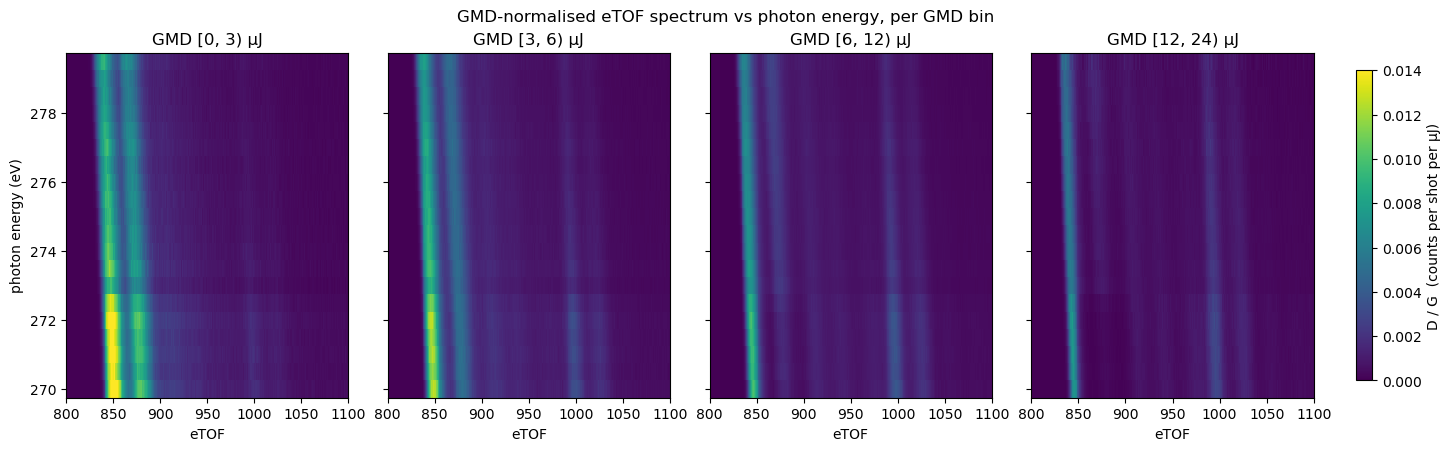

In [149]:
def _energy_edges(e):
    """Half-step edges around a non-uniform energy axis for pcolormesh."""
    e = np.asarray(e, dtype=np.float64)
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])

e_edges = _energy_edges(energies)

finite = stack[np.isfinite(stack)]
vmin = VMIN if VMIN is not None else float(np.nanpercentile(finite, 1))
vmax = VMAX if VMAX is not None else float(np.nanpercentile(finite, 99))

vmin = 0
vmax = 0.014

fig, axes = plt.subplots(
    1, n_gmd, figsize=(3.6 * n_gmd, 4.4), sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for g, ax in enumerate(axes):
    pcm = ax.pcolormesh(
        tof_edges, e_edges, stack[:, g, :],
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto",
    )
    ax.set_title(
        f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g + 1]:.2g}) µJ"
    )
    ax.set_xlabel("eTOF")
    if TOF_RANGE[0] is not None or TOF_RANGE[1] is not None:
        ax.set_xlim(TOF_RANGE[0], TOF_RANGE[1])
    ax.set_xlim(800,1100)

axes[0].set_ylabel("photon energy (eV)")
cbar = fig.colorbar(pcm, ax=axes, location="right", shrink=0.9, pad=0.02)
cbar.set_label("D / G  (counts per shot per µJ)")
fig.suptitle("GMD-normalised eTOF spectrum vs photon energy, per GMD bin")
plt.show()

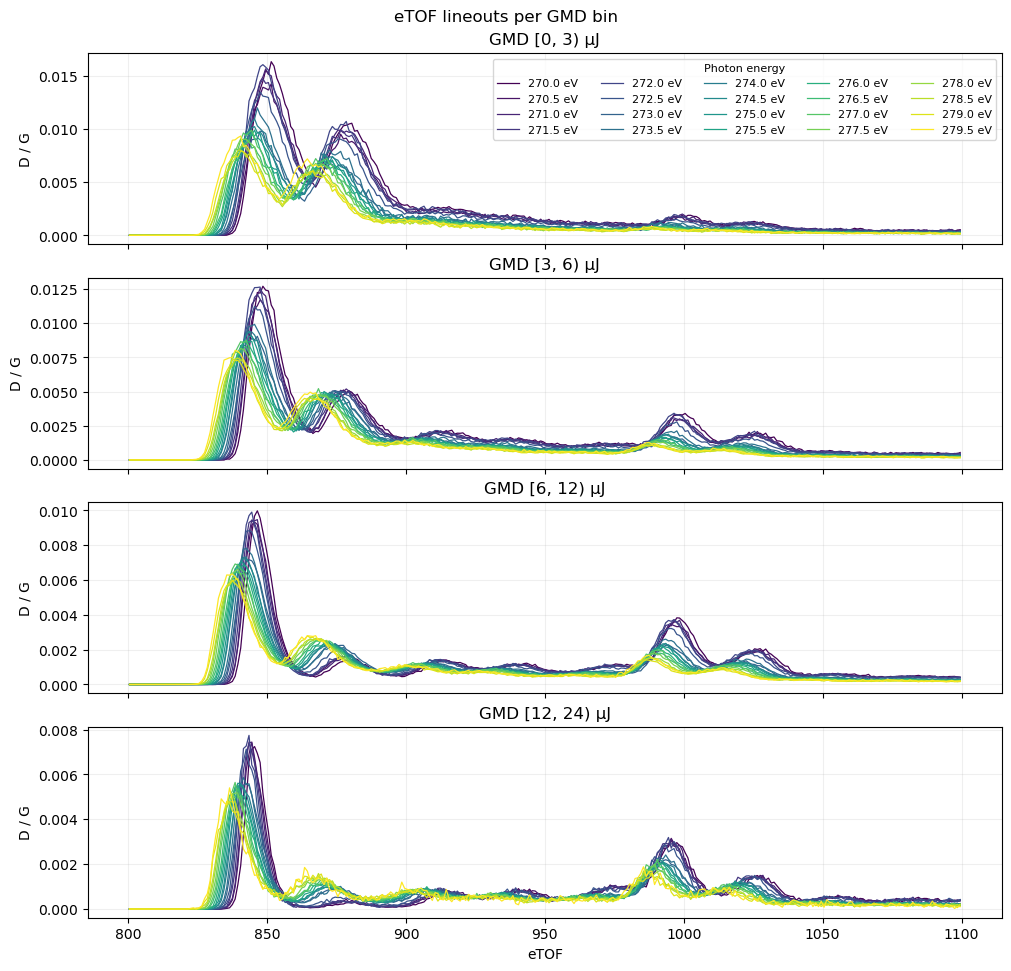

In [154]:
# --- Lineout plot: eTOF spectra per GMD bin -------------------------

ENERGIES_TO_PLOT = None
# Example if you want fewer curves:
# ENERGIES_TO_PLOT = [270.0, 272.0, 274.0, 276.0, 278.0, 279.5]

TOF_LINEOUT_RANGE = (800, 1100)

# Optional smoothing only for visual comparison.
# Set to 1 for no smoothing.
SMOOTH_BINS = 1
# SMOOTH_BINS = 5

def _smooth_1d(y, width):
    if width is None or width <= 1:
        return y
    kernel = np.ones(int(width), dtype=float) / float(width)
    return np.convolve(y, kernel, mode="same")

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

if ENERGIES_TO_PLOT is None:
    plot_idx = np.arange(len(energies))
else:
    plot_idx = []
    for e in ENERGIES_TO_PLOT:
        i = int(np.argmin(np.abs(energies - e)))
        if abs(energies[i] - e) > 1e-6:
            print(f"warning: requested {e} eV, using nearest {energies[i]} eV")
        plot_idx.append(i)
    plot_idx = np.array(plot_idx, dtype=int)

xmask = np.ones_like(tof_cent, dtype=bool)
if TOF_LINEOUT_RANGE[0] is not None:
    xmask &= tof_cent >= TOF_LINEOUT_RANGE[0]
if TOF_LINEOUT_RANGE[1] is not None:
    xmask &= tof_cent <= TOF_LINEOUT_RANGE[1]

fig, axes = plt.subplots(
    n_gmd, 1,
    figsize=(10, 2.4 * n_gmd),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(plot_idx)))

for g, ax in enumerate(axes):
    for c, i in zip(colors, plot_idx):
        y = stack[i, g, :]
        y = _smooth_1d(y, SMOOTH_BINS)
        ax.plot(
            tof_cent[xmask],
            y[xmask],
            lw=0.9,
            color=c,
            label=f"{energies[i]:.1f} eV",
        )

    ax.set_title(f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g + 1]:.2g}) µJ")
    ax.set_ylabel("D / G")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("eTOF")
axes[0].legend(
    title="Photon energy",
    ncols=min(5, len(plot_idx)),
    fontsize=8,
    title_fontsize=8,
    loc="upper right",
)

fig.suptitle("eTOF lineouts per GMD bin")
plt.show()

## Subtraction

In [155]:
# --- Load eTOF -> KE calibration ------------------------------------

from pathlib import Path
import json
import numpy as np

CALIB_PATH = Path(config.COMBINED_DIR).parent / "Calibrations" / "etof_energy_calibration_t0_scan.json"

with open(CALIB_PATH, "r", encoding="utf-8") as fh:
    calib = json.load(fh)

best_t0 = calib["t0_tof_units"]
best_slope = calib["slope_eV_tof_unit2"]
best_E0 = calib["E0_eV"]

def KE_from_TOF(t):
    t = np.asarray(t, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        ke = best_slope / (t - best_t0)**2 + best_E0
    return np.where(t > best_t0, ke, np.nan)

tof_to_ke = KE_from_TOF

print("Loaded eTOF calibration:")
print(f"  path  = {CALIB_PATH}")
print(f"  t0    = {best_t0:.6f} TOF units")
print(f"  slope = {best_slope:.6e} eV * TOF_unit^2")
print(f"  E0    = {best_E0:.6f} eV")

if "effective_length_mm" in calib:
    print(f"  L     = {calib['effective_length_mm']:.2f} mm")

if "fit_quality" in calib:
    print(f"  RMSE  = {calib['fit_quality'].get('rmse_eV', np.nan):.4f} eV")
    print(f"  R²    = {calib['fit_quality'].get('r2', np.nan):.8f}")

Loaded eTOF calibration:
  path  = /asap3/flash/gpfs/fl24/2026/data/11022188/processed/Calibrations/etof_energy_calibration_t0_scan.json
  t0    = 70.317117 TOF units
  slope = 1.726561e+08 eV * TOF_unit^2
  E0    = -32.015747 eV
  L     = 779.32 mm
  RMSE  = 1.1566 eV
  R²    = 0.99982907


In [167]:
# --- Helpers for plotting TOF-binned maps on calibrated KE axis -------

def _tof_window_to_ke_edges_and_data(tof_edges, data, tof_range):
    """
    Slice TOF-binned data to a TOF window, convert bin edges to KE,
    and reverse columns so KE increases left-to-right.
    """
    tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

    mask = np.ones_like(tof_cent, dtype=bool)
    if tof_range[0] is not None:
        mask &= tof_cent >= tof_range[0]
    if tof_range[1] is not None:
        mask &= tof_cent <= tof_range[1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        raise ValueError(f"No TOF bins inside range {tof_range}")

    lo = int(idx[0])
    hi = int(idx[-1]) + 1

    data_s = data[..., lo:hi]
    ke_edges = tof_to_ke(tof_edges[lo:hi + 1])

    good_edges = np.isfinite(ke_edges)
    if not np.all(good_edges):
        raise ValueError(
            "Some KE edges are NaN. Choose a TOF range fully above t0."
        )

    # Convert counts per TOF bin to counts per eV.
    # Must be done before/after reversing consistently with ke_edges.
    ke_widths = np.abs(np.diff(ke_edges))

    with np.errstate(invalid="ignore", divide="ignore"):
        data_s = data_s / ke_widths

    # TOF increases while KE usually decreases, so reverse to increasing KE.
    if ke_edges[0] > ke_edges[-1]:
        ke_edges = ke_edges[::-1]
        data_s = data_s[..., ::-1]

    return ke_edges, data_s


def _tof_lineout_to_ke(tof_cent, y, tof_range):
    mask = np.ones_like(tof_cent, dtype=bool)
    if tof_range[0] is not None:
        mask &= tof_cent >= tof_range[0]
    if tof_range[1] is not None:
        mask &= tof_cent <= tof_range[1]

    ke = tof_to_ke(tof_cent[mask])
    yy = y[mask]

    good = np.isfinite(ke)
    ke = ke[good]
    yy = yy[good]

    order = np.argsort(ke)
    return ke[order], yy[order]

In [168]:
# --- Match residual-gas background to signal energy/GMD/TOF grid -----

BG_SCALE = 1.0
ENERGY_TOL = 1e-6

if not np.array_equal(tof_edges, bg_agg_tof_edges):
    raise ValueError("Signal and background TOF edges do not match.")

if not np.array_equal(gmd_edges, bg_agg_gmd_edges):
    raise ValueError("Signal and background GMD edges do not match.")

bg_on_signal = np.full_like(stack, np.nan, dtype=np.float64)
has_background = np.zeros(len(energies), dtype=bool)
bg_match_index = np.full(len(energies), -1, dtype=int)

for i, e in enumerate(energies):
    matches = np.where(np.isclose(bg_agg_energies, e, atol=ENERGY_TOL))[0]
    if len(matches) == 0:
        continue
    j = int(matches[0])
    bg_on_signal[i] = bg_agg_stack[j]
    has_background[i] = True
    bg_match_index[i] = j

# Partial subtraction:
# where background exists -> signal - scaled background
# where background does not exist -> keep raw signal unchanged
stack_bgsub_partial = stack.copy()
stack_bgsub_partial[has_background] = (
    stack[has_background] - BG_SCALE * bg_on_signal[has_background]
)

print("Signal energies:")
print(energies)
print("Background energies:")
print(bg_agg_energies)
print("Matched energies:")
for i, ok in enumerate(has_background):
    if ok:
        print(f"  {energies[i]:7.2f} eV  signal row {i} <- background row {bg_match_index[i]}")
print("No measured background for:")
print(energies[~has_background])

Signal energies:
[270.  270.5 271.  271.5 272.  272.5 273.  273.5 274.  274.5 275.  275.5
 276.  276.5 277.  277.5 278.  278.5 279.  279.5]
Background energies:
[271.  271.5 272.  272.5 273.  273.5 274.  274.5 275. ]
Matched energies:
   271.00 eV  signal row 2 <- background row 0
   271.50 eV  signal row 3 <- background row 1
   272.00 eV  signal row 4 <- background row 2
   272.50 eV  signal row 5 <- background row 3
   273.00 eV  signal row 6 <- background row 4
   273.50 eV  signal row 7 <- background row 5
   274.00 eV  signal row 8 <- background row 6
   274.50 eV  signal row 9 <- background row 7
   275.00 eV  signal row 10 <- background row 8
No measured background for:
[270.  270.5 275.5 276.  276.5 277.  277.5 278.  278.5 279.  279.5]


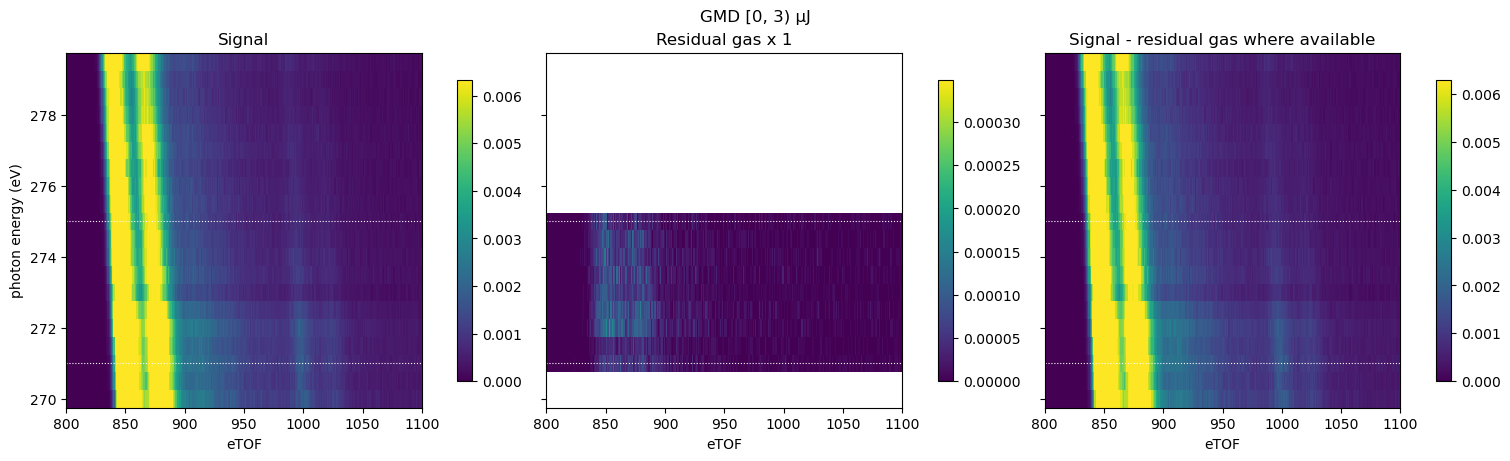

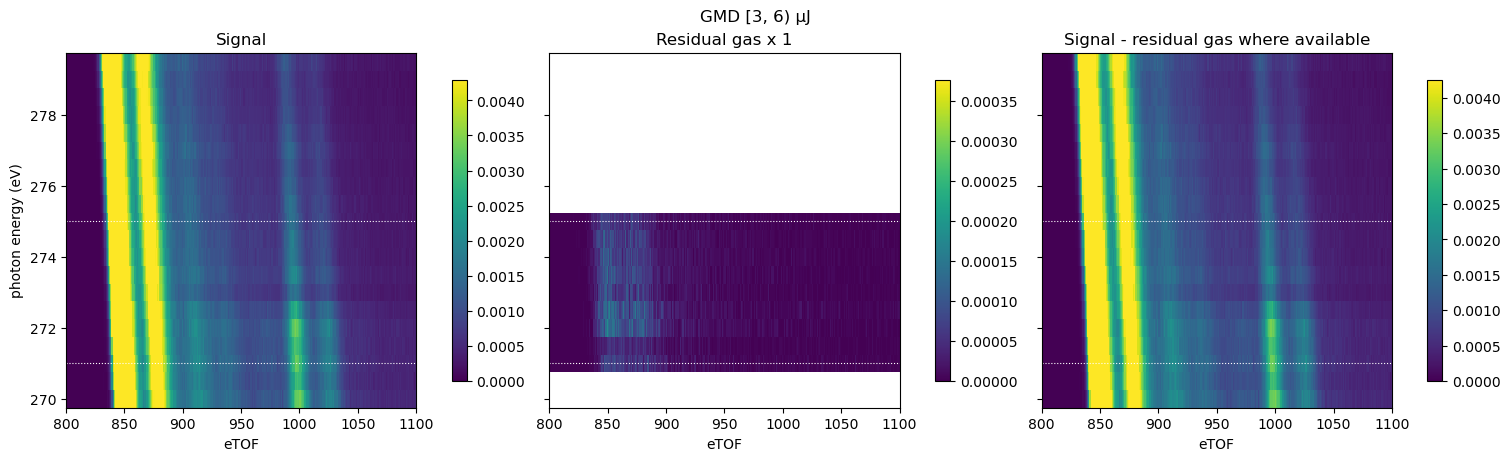

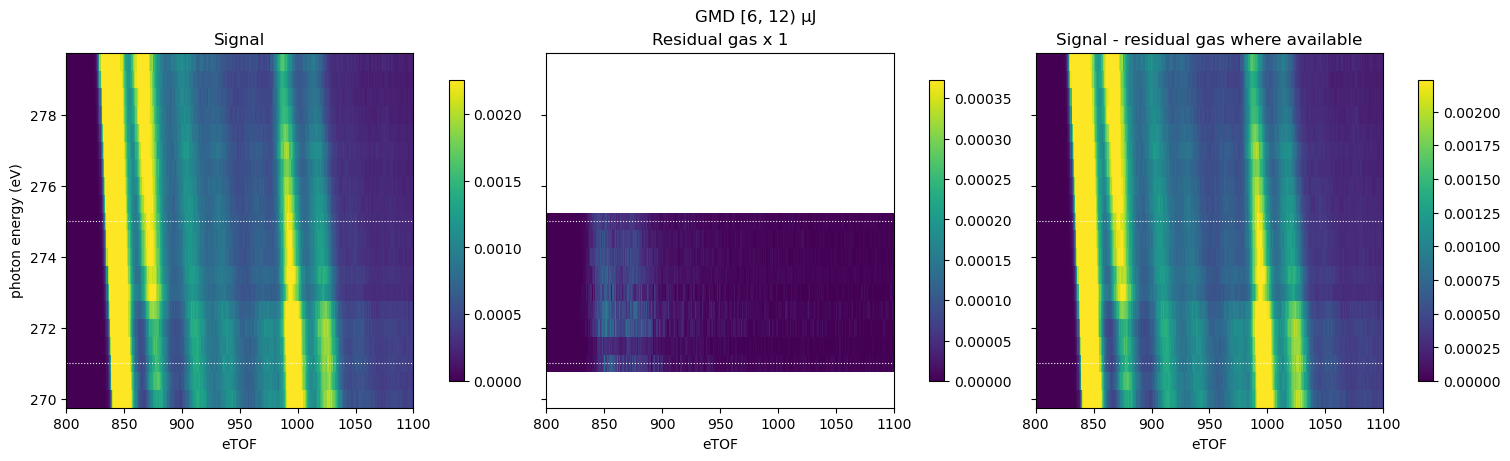

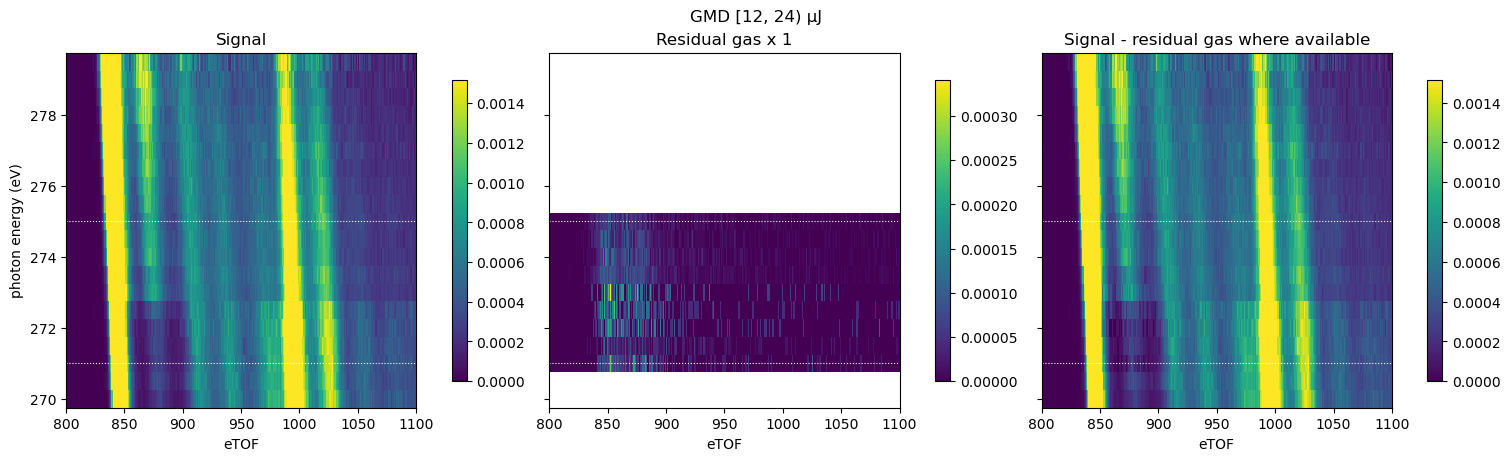

In [169]:
# --- Plot raw signal, matched background, and partial subtraction -----

TOF_RANGE = (800, 1100)

def _energy_edges(e):
    e = np.asarray(e, dtype=np.float64)
    if len(e) == 1:
        return np.array([e[0] - 0.25, e[0] + 0.25])
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])

def _robust_limits(arr, p_lo=1, p_hi=99.5):
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.nanpercentile(finite, p_lo)), float(np.nanpercentile(finite, p_hi))

e_edges = _energy_edges(energies)

for g in range(len(gmd_edges) - 1):
    raw = stack[:, g, :]
    bg = bg_on_signal[:, g, :]
    sub = stack_bgsub_partial[:, g, :]

    raw_vmin, raw_vmax = _robust_limits(raw)
    bg_vmin, bg_vmax = _robust_limits(bg)
    sub_vmin, sub_vmax = _robust_limits(sub)

    fig, axes = plt.subplots(
        1, 3, figsize=(15, 4.5), sharey=True, constrained_layout=True
    )

    panels = [
        (raw, raw_vmin, raw_vmax, "Signal"),
        (bg, bg_vmin, bg_vmax, f"Residual gas x {BG_SCALE:g}"),
        (sub, sub_vmin, sub_vmax, "Signal - residual gas where available"),
    ]

    for ax, (data, vmin, vmax, title) in zip(axes, panels):
        pcm = ax.pcolormesh(
            tof_edges,
            e_edges,
            data,
            shading="auto",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("eTOF")
        ax.set_xlim(*TOF_RANGE)
        fig.colorbar(pcm, ax=ax, shrink=0.85)

        # Mark boundary of measured background region.
        if has_background.any():
            ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
            ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)

    axes[0].set_ylabel("photon energy (eV)")
    fig.suptitle(f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g+1]:.2g}) µJ")
    plt.show()

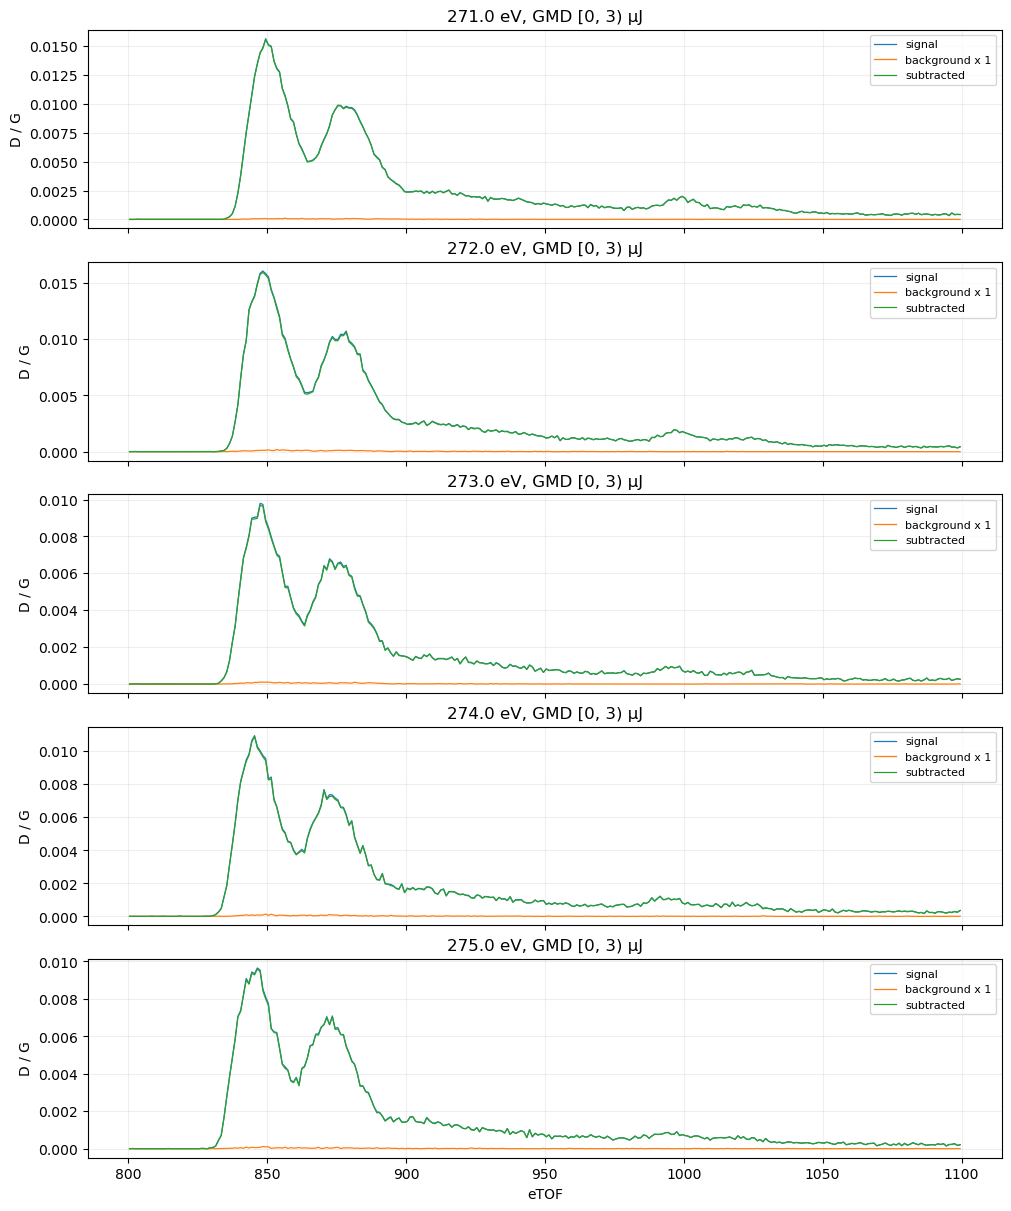

In [170]:
# --- Lineouts: raw signal vs background vs subtracted ----------------

ENERGIES_TO_COMPARE = [271.0, 272.0, 273.0, 274.0, 275.0]
GMD_BIN = 0
TOF_LINEOUT_RANGE = (800, 1100)

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
xmask = (tof_cent >= TOF_LINEOUT_RANGE[0]) & (tof_cent <= TOF_LINEOUT_RANGE[1])

fig, axes = plt.subplots(
    len(ENERGIES_TO_COMPARE), 1,
    figsize=(10, 2.4 * len(ENERGIES_TO_COMPARE)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, e in zip(axes, ENERGIES_TO_COMPARE):
    idx = np.where(np.isclose(energies, e))[0]
    if len(idx) == 0:
        ax.text(0.5, 0.5, f"{e:.1f} eV not in signal", transform=ax.transAxes)
        continue

    i = int(idx[0])

    ax.plot(tof_cent[xmask], stack[i, GMD_BIN, xmask], lw=0.9, label="signal")

    if has_background[i]:
        ax.plot(
            tof_cent[xmask],
            BG_SCALE * bg_on_signal[i, GMD_BIN, xmask],
            lw=0.9,
            label=f"background x {BG_SCALE:g}",
        )
        ax.plot(
            tof_cent[xmask],
            stack_bgsub_partial[i, GMD_BIN, xmask],
            lw=0.9,
            label="subtracted",
        )
    else:
        ax.plot(
            tof_cent[xmask],
            stack_bgsub_partial[i, GMD_BIN, xmask],
            lw=0.9,
            label="unchanged",
        )

    ax.set_title(f"{e:.1f} eV, GMD [{gmd_edges[GMD_BIN]:.2g}, {gmd_edges[GMD_BIN+1]:.2g}) µJ")
    ax.set_ylabel("D / G")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("eTOF")
plt.show()

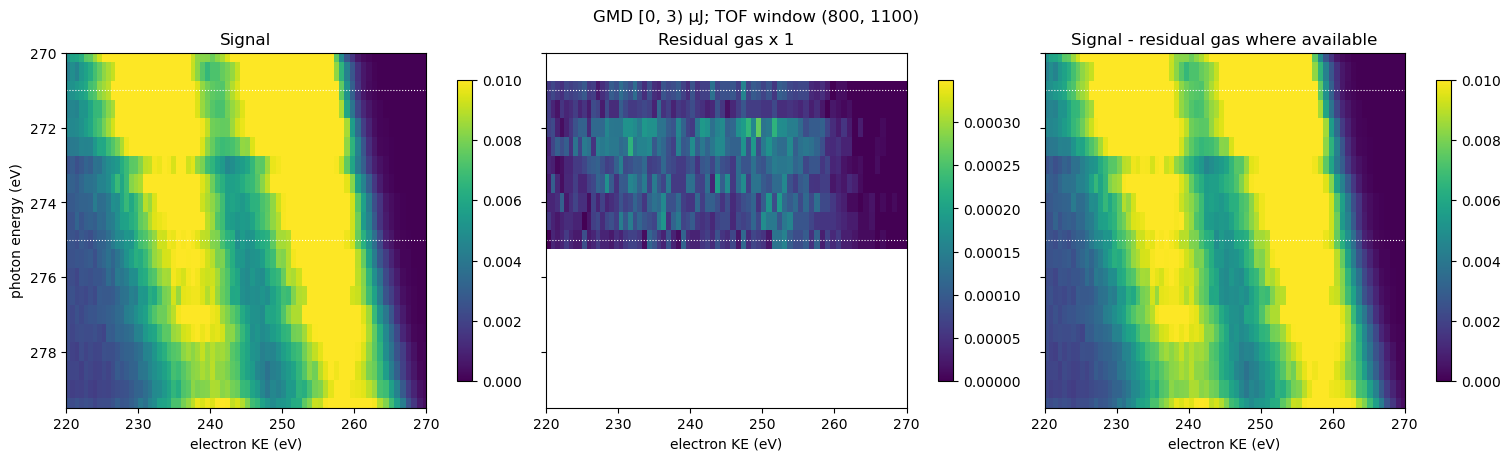

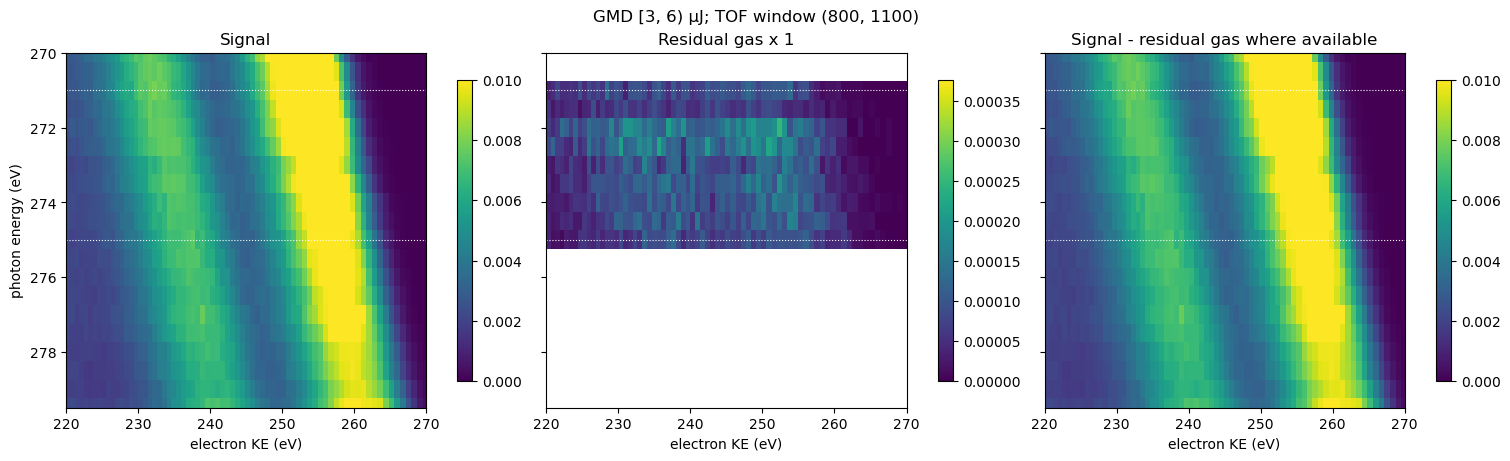

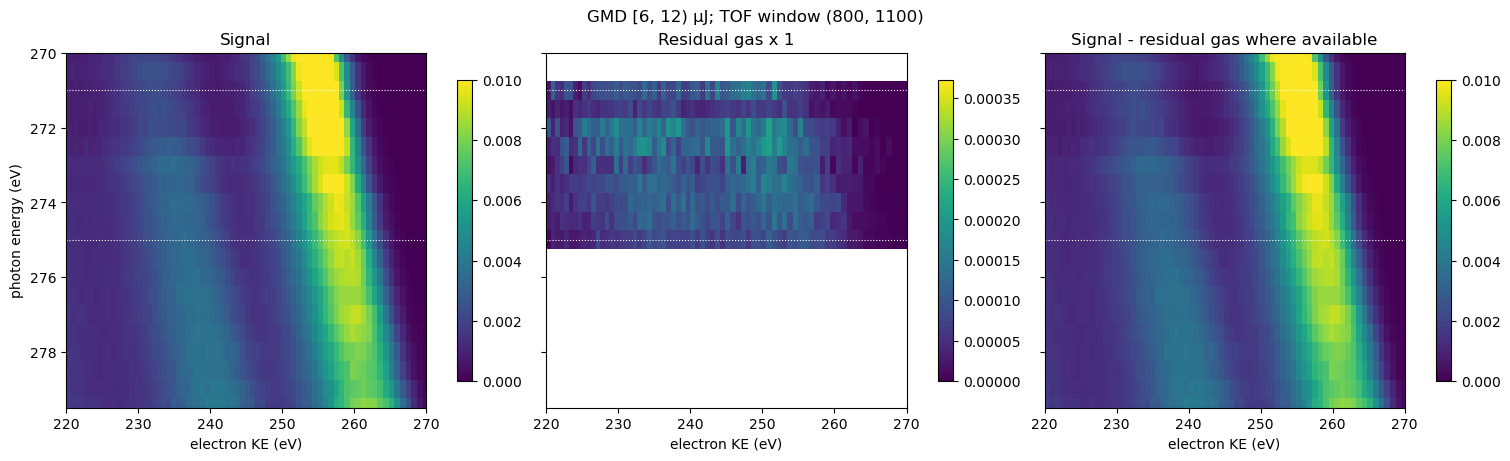

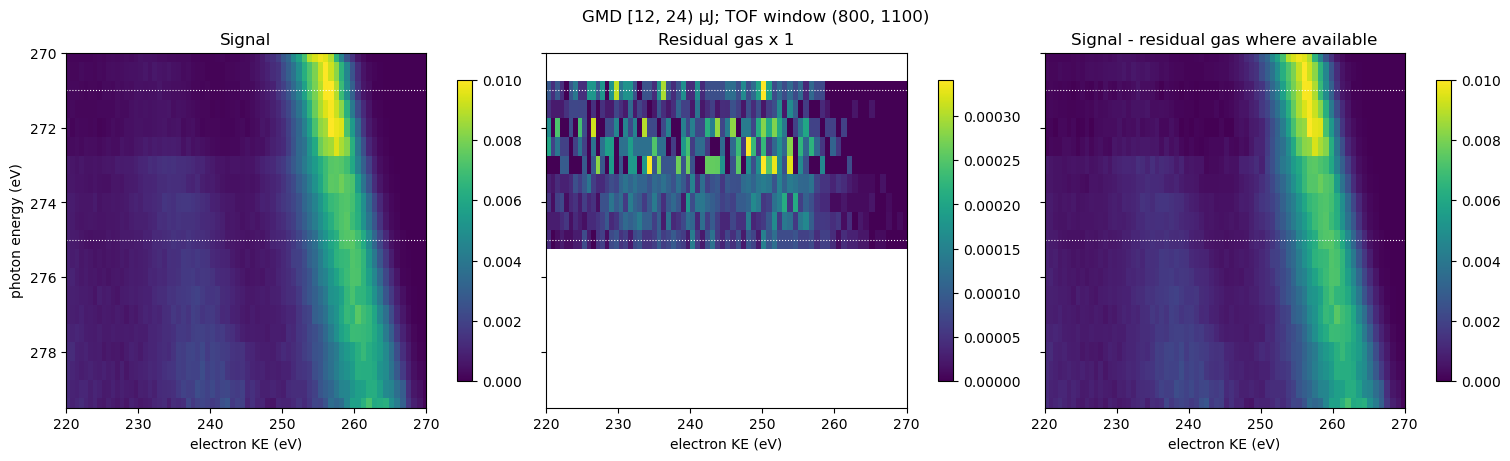

In [171]:
# --- Plot raw signal, matched background, and partial subtraction on KE axis -----

TOF_RANGE = (800, 1100)

RAW_VMAX = 0.01      # change this
BG_VMAX = None       # keep auto
SUB_VMAX = RAW_VMAX      # change this

def _energy_edges(e):
    e = np.asarray(e, dtype=np.float64)
    if len(e) == 1:
        return np.array([e[0] - 0.25, e[0] + 0.25])
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])

def _robust_limits(arr, p_lo=1, p_hi=99.5):
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.nanpercentile(finite, p_lo)), float(np.nanpercentile(finite, p_hi))

e_edges = _energy_edges(energies)

for g in range(len(gmd_edges) - 1):
    raw = stack[:, g, :]
    bg = bg_on_signal[:, g, :]
    sub = stack_bgsub_partial[:, g, :]

    raw_vmin, raw_vmax = _robust_limits(raw)
    bg_vmin, bg_vmax = _robust_limits(bg)
    sub_vmin, sub_vmax = _robust_limits(sub)
    
    if RAW_VMAX is not None:
        raw_vmax = RAW_VMAX
    if BG_VMAX is not None:
        bg_vmax = BG_VMAX
    if SUB_VMAX is not None:
        sub_vmax = SUB_VMAX

    fig, axes = plt.subplots(
        1, 3, figsize=(15, 4.5), sharey=True, constrained_layout=True
    )

    panels = [
        (raw, raw_vmin, raw_vmax, "Signal"),
        (bg, bg_vmin, bg_vmax, f"Residual gas x {BG_SCALE:g}"),
        (sub, sub_vmin, sub_vmax, "Signal - residual gas where available"),
    ]

    for ax, (data, vmin, vmax, title) in zip(axes, panels):
        ke_edges, data_ke = _tof_window_to_ke_edges_and_data(
            tof_edges, data, TOF_RANGE
        )

        pcm = ax.pcolormesh(
            ke_edges,
            e_edges,
            data_ke,
            shading="auto",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(title)
        ax.set_xlabel("electron KE (eV)")
        fig.colorbar(pcm, ax=ax, shrink=0.85)

        if has_background.any():
            ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
            ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)
        ax.set_ylim(279.5,270)
        ax.set_xlim(220,270)

    axes[0].set_ylabel("photon energy (eV)")
    fig.suptitle(
        f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g+1]:.2g}) µJ; "
        f"TOF window {TOF_RANGE}"
    )
    plt.show()

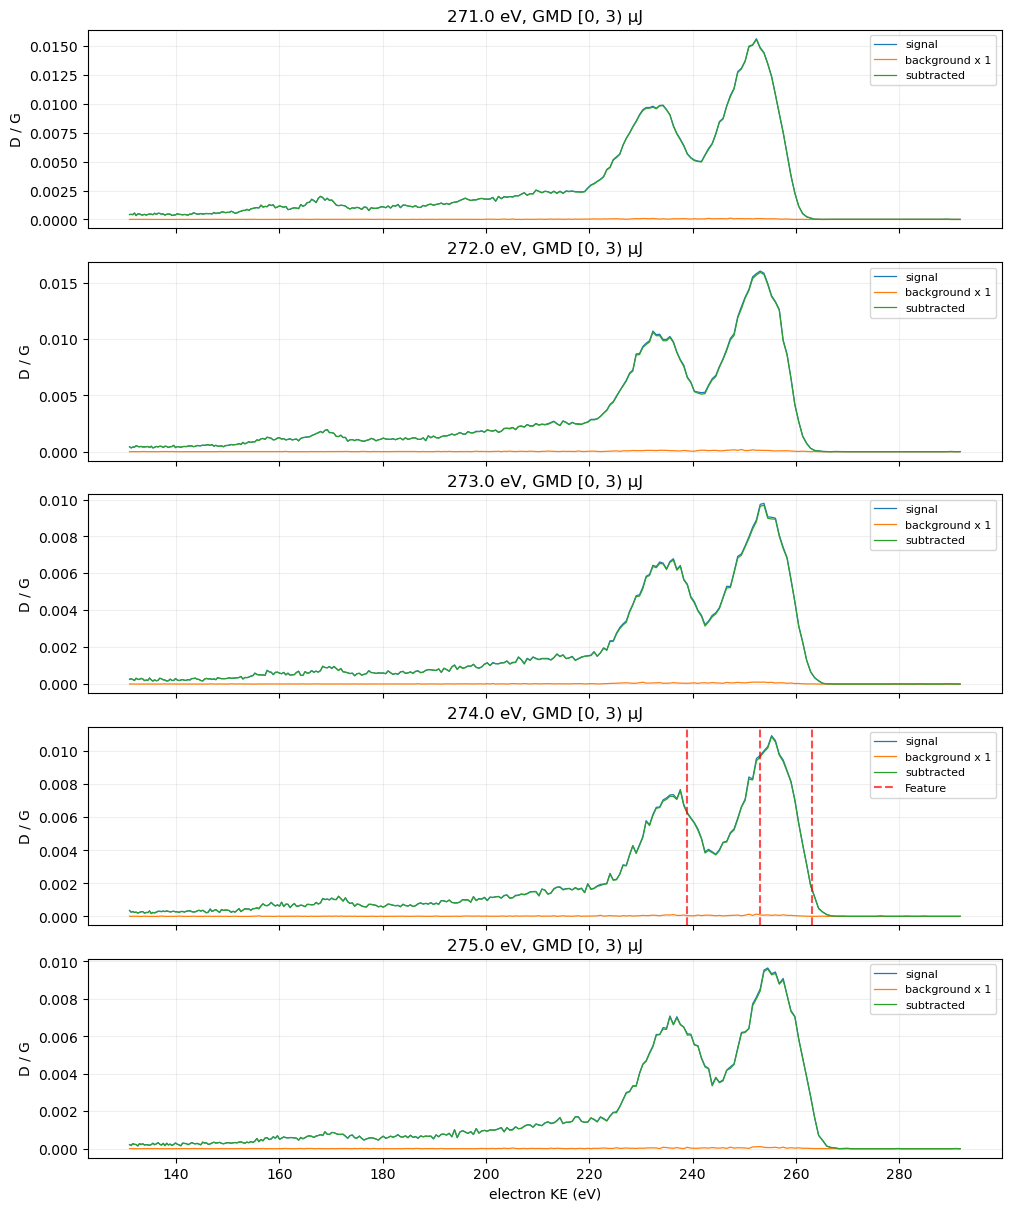

In [172]:
# --- Lineouts: raw signal vs background vs subtracted on KE axis ------

ENERGIES_TO_COMPARE = [271.0, 272.0, 273.0, 274.0, 275.0]
GMD_BIN = 0
TOF_LINEOUT_RANGE = (800, 1100)

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

fig, axes = plt.subplots(
    len(ENERGIES_TO_COMPARE), 1,
    figsize=(10, 2.4 * len(ENERGIES_TO_COMPARE)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for idx_plot, (ax, e) in enumerate(zip(axes, ENERGIES_TO_COMPARE)):
    idx = np.where(np.isclose(energies, e))[0]
    if len(idx) == 0:
        ax.text(0.5, 0.5, f"{e:.1f} eV not in signal", transform=ax.transAxes)
        continue

    i = int(idx[0])

    ke, sig_y = _tof_lineout_to_ke(
        tof_cent, stack[i, GMD_BIN, :], TOF_LINEOUT_RANGE
    )
    ax.plot(ke, sig_y, lw=0.9, label="signal")

    if has_background[i]:
        _, bg_y = _tof_lineout_to_ke(
            tof_cent, BG_SCALE * bg_on_signal[i, GMD_BIN, :], TOF_LINEOUT_RANGE
        )
        _, sub_y = _tof_lineout_to_ke(
            tof_cent, stack_bgsub_partial[i, GMD_BIN, :], TOF_LINEOUT_RANGE
        )

        ax.plot(ke, bg_y, lw=0.9, label=f"background x {BG_SCALE:g}")
        ax.plot(ke, sub_y, lw=0.9, label="subtracted")
    else:
        _, sub_y = _tof_lineout_to_ke(
            tof_cent, stack_bgsub_partial[i, GMD_BIN, :], TOF_LINEOUT_RANGE
        )
        ax.plot(ke, sub_y, lw=0.9, label="unchanged")

    if idx_plot == 3: 
        lines_x = [273.2-10, 273.2-20.2, 273.2-34.3] 
        for x_val in lines_x:
            ax.axvline(x=x_val, color="red", linestyle="--", alpha=0.7, label="Feature" if x_val == lines_x[0] else "")

    ax.set_title(
        f"{e:.1f} eV, GMD [{gmd_edges[GMD_BIN]:.2g}, {gmd_edges[GMD_BIN+1]:.2g}) µJ"
    )
    ax.set_ylabel("D / G")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("electron KE (eV)")
plt.show()

In [173]:
# --- Combine all GMD bins into one total map -------------------------

def _weighted_mean_over_gmd(arr, weights):
    """
    arr:     (n_energy, n_gmd, n_tof)
    weights: (n_energy, n_gmd), e.g. n_shots

    Returns:
        (n_energy, n_tof)
    """
    arr = np.asarray(arr, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = np.isfinite(arr) & np.isfinite(weights[:, :, None]) & (weights[:, :, None] > 0)
    w = np.where(valid, weights[:, :, None], 0.0)
    x = np.where(valid, arr, 0.0)

    denom = np.sum(w, axis=1)
    out = np.sum(x * w, axis=1) / denom
    out[denom == 0] = np.nan
    return out


# Signal weights: use signal aggregate shot counts.
signal_total = _weighted_mean_over_gmd(stack, n_shots)

# Background on signal grid: use the signal weights so the combined background
# matches the GMD-bin mixture of the signal at each energy.
background_total = _weighted_mean_over_gmd(bg_on_signal, n_shots)

# Partial subtraction: exact-energy background subtracted where available,
# unchanged otherwise, already GMD-bin resolved; now combine the result.
subtracted_total = _weighted_mean_over_gmd(stack_bgsub_partial, n_shots)

print("signal_total:", signal_total.shape)
print("background_total:", background_total.shape)
print("subtracted_total:", subtracted_total.shape)

signal_total: (20, 5000)
background_total: (20, 5000)
subtracted_total: (20, 5000)


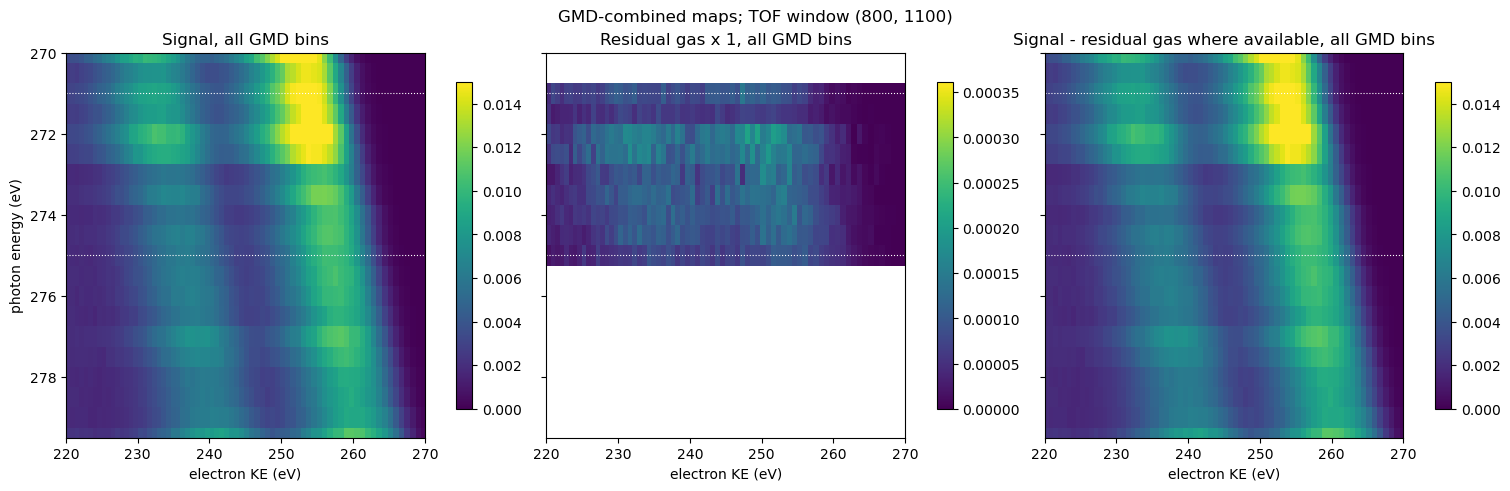

In [174]:
# --- Plot total GMD-combined signal/background/subtracted maps --------
import matplotlib.colors as mcolors
w_b_r = mcolors.LinearSegmentedColormap.from_list("WhiteBlueRed", ["white", "blue", "red"])

TOF_RANGE = (800, 1100)

RAW_VMAX = 0.015      # change this
BG_VMAX = None       # keep auto
SUB_VMAX = RAW_VMAX      # change this



e_edges = _energy_edges(energies)

panels = [
    (signal_total, RAW_VMAX, "Signal, all GMD bins"),
    (background_total, BG_VMAX, f"Residual gas x {BG_SCALE:g}, all GMD bins"),
    (subtracted_total, SUB_VMAX, "Signal - residual gas where available, all GMD bins"),
]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 4.8), sharey=True, constrained_layout=True
)

for ax, (data, manual_vmax, title) in zip(axes, panels):
    vmin, vmax = _robust_limits(data)
    if manual_vmax is not None:
        vmax = manual_vmax

    ke_edges, data_ke = _tof_window_to_ke_edges_and_data(
        tof_edges, data, TOF_RANGE
    )

    pcm = ax.pcolormesh(
        ke_edges,
        e_edges,
        data_ke,
        shading="auto",
        cmap="viridis",
        #cmap=w_b_r,  This is the red and blue map similar to the paper, but not quite, as the red in the paper reached low4er values
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(title)
    ax.set_xlabel("electron KE (eV)")
    fig.colorbar(pcm, ax=ax, shrink=0.85)

    if has_background.any():
        ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
        ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)

    ax.set_ylim(279.5,270)
    ax.set_xlim(220,270)

axes[0].set_ylabel("photon energy (eV)")
fig.suptitle(f"GMD-combined maps; TOF window {TOF_RANGE}")
plt.show()

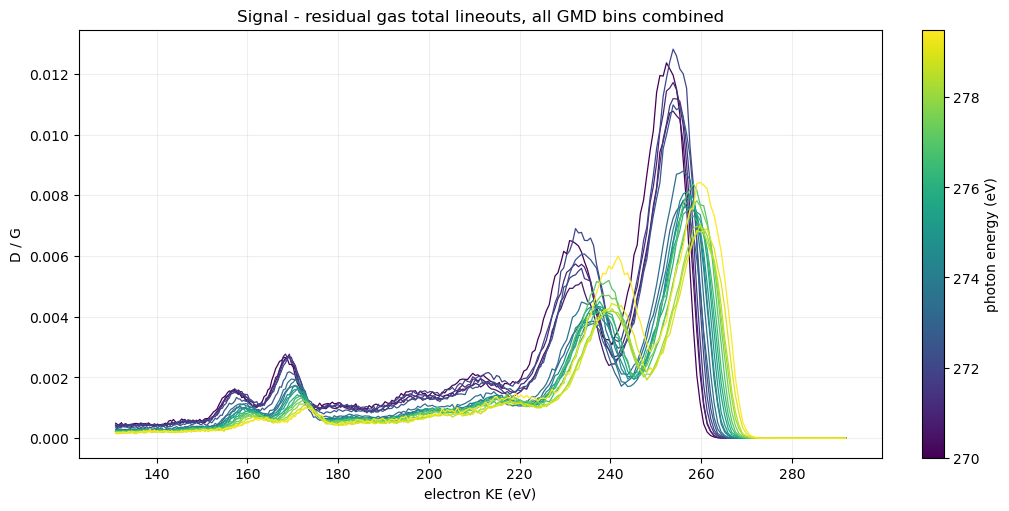

In [175]:
# --- Total-map lineouts: all photon energies, calibrated KE ----------

TOF_LINEOUT_RANGE = (800, 1100)

# Choose which total map to plot:
TOTAL_MAP = subtracted_total
TITLE_LABEL = "Signal - residual gas total"

# Alternatives:
# TOTAL_MAP = subtracted_total
# TITLE_LABEL = "Signal - residual gas total"
#
# TOTAL_MAP = background_total
# TITLE_LABEL = "Residual gas total"

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

tof_mask = np.ones_like(tof_cent, dtype=bool)
if TOF_LINEOUT_RANGE[0] is not None:
    tof_mask &= tof_cent >= TOF_LINEOUT_RANGE[0]
if TOF_LINEOUT_RANGE[1] is not None:
    tof_mask &= tof_cent <= TOF_LINEOUT_RANGE[1]

ke = tof_to_ke(tof_cent[tof_mask])
good = np.isfinite(ke)
ke = ke[good]

order = np.argsort(ke)
ke_plot = ke[order]

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=np.nanmin(energies), vmax=np.nanmax(energies))

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

for i, e in enumerate(energies):
    y = TOTAL_MAP[i, tof_mask][good][order]
    ax.plot(
        ke_plot,
        y,
        lw=0.9,
        color=cmap(norm(e)),
        label=f"{e:.1f} eV",
    )

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("photon energy (eV)")

ax.set_xlabel("electron KE (eV)")
ax.set_ylabel("D / G")
ax.set_title(f"{TITLE_LABEL} lineouts, all GMD bins combined")
ax.grid(alpha=0.2)

plt.show()

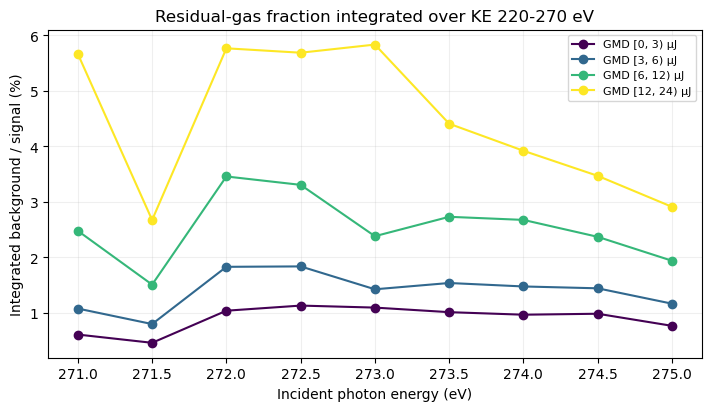

Integrated over KE range: 220-270 eV
Number of TOF/KE bins included: 72


In [176]:
# --- Integrated background/signal fraction vs photon energy ----------
#     One curve per GMD bin, integrated over a KE window.

KE_COMPARE_RANGE = (220, 270)  # eV

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
ke_cent = tof_to_ke(tof_cent)

ke_mask = (
    np.isfinite(ke_cent)
    & (ke_cent >= KE_COMPARE_RANGE[0])
    & (ke_cent <= KE_COMPARE_RANGE[1])
)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

cmap = plt.get_cmap("viridis")
n_gmd = len(gmd_edges) - 1

for GMD_BIN in range(n_gmd):
    e_plot = []
    frac_sum = []

    for i, e in enumerate(energies):
        if not has_background[i]:
            continue

        sig = stack[i, GMD_BIN, ke_mask]
        bg = bg_on_signal[i, GMD_BIN, ke_mask]

        sig_sum = np.nansum(sig)
        bg_sum = np.nansum(bg)

        e_plot.append(e)
        frac_sum.append(100 * bg_sum / sig_sum if sig_sum else np.nan)

    color = cmap(GMD_BIN / max(n_gmd - 1, 1))
    label = f"GMD [{gmd_edges[GMD_BIN]:.2g}, {gmd_edges[GMD_BIN+1]:.2g}) µJ"

    ax.plot(e_plot, frac_sum, "o-", color=color, label=label)

ax.set_xlabel("Incident photon energy (eV)")
ax.set_ylabel("Integrated background / signal (%)")
ax.set_title(f"Residual-gas fraction integrated over KE {KE_COMPARE_RANGE[0]}-{KE_COMPARE_RANGE[1]} eV")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)

plt.show()

print(f"Integrated over KE range: {KE_COMPARE_RANGE[0]}-{KE_COMPARE_RANGE[1]} eV")
print(f"Number of TOF/KE bins included: {np.count_nonzero(ke_mask)}")

## Binding energy representation

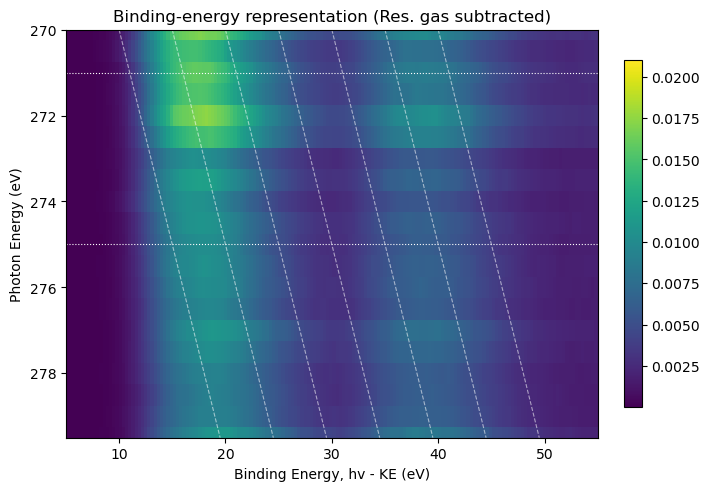

In [213]:
# --- Binding-energy map from already-calibrated KE map -----------------

BE_RANGE = (5.0, 55.0)
BE_STEP = 0.3

be_centres = np.arange(BE_RANGE[0], BE_RANGE[1] + BE_STEP, BE_STEP)
be_edges = _energy_edges(be_centres)


def kinetic_to_binding_map(signal_ke_map, photon_energies, ke_edges, be_centres):
    """
    Remap S(hv, KE) onto S(hv, apparent binding energy),
    where BE = hv - KE.

    signal_ke_map shape must be (n_photon_energies, n_ke_bins).
    """
    signal_ke_map = np.asarray(signal_ke_map, dtype=float)
    photon_energies = np.asarray(photon_energies, dtype=float)
    ke_centres = 0.5 * (ke_edges[:-1] + ke_edges[1:])
    be_centres = np.asarray(be_centres, dtype=float)

    if signal_ke_map.shape != (len(photon_energies), len(ke_centres)):
        raise ValueError(
            f"shape mismatch: signal_ke_map has {signal_ke_map.shape}, "
            f"expected {(len(photon_energies), len(ke_centres))}"
        )

    be_map = np.full((len(photon_energies), len(be_centres)), np.nan)

    for row, hv in enumerate(photon_energies):
        apparent_be = hv - ke_centres
        order = np.argsort(apparent_be)

        be_map[row] = np.interp(
            be_centres,
            apparent_be[order],
            signal_ke_map[row, order],
            left=np.nan,
            right=np.nan,
        )

    return be_map


ke_edges, subtracted_ke = _tof_window_to_ke_edges_and_data(
    tof_edges,
    subtracted_total,
    TOF_RANGE,
)

binding_map = kinetic_to_binding_map(
    signal_ke_map=subtracted_ke,
    photon_energies=energies,
    ke_edges=ke_edges,
    be_centres=be_centres,
)

vmin, vmax = _robust_limits(binding_map)
if SUB_VMAX is not None:
    vmax = SUB_VMAX * 1.4

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

pcm = ax.pcolormesh(
    be_edges,
    e_edges,
    binding_map,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, shrink=0.85)
ax.set_xlabel("Binding Energy, hv - KE (eV)")
ax.set_ylabel("Photon Energy (eV)")
ax.set_title("Binding-energy representation (Res. gas subtracted)")

# Fixed-KE guide lines.
# In BE coordinates, a feature at constant KE follows:
#   BE = photon_energy - fixed_KE
fixed_ke_values = [230, 235, 240, 245, 250, 255, 260]

for fixed_ke in fixed_ke_values:
    expected_be = energies - fixed_ke

    visible = (
        np.isfinite(expected_be)
        & (expected_be >= BE_RANGE[0])
        & (expected_be <= BE_RANGE[1])
    )

    if np.any(visible):
        ax.plot(
            expected_be[visible],
            energies[visible],
            linestyle="--",
            linewidth=0.8,
            alpha=0.55,
            color="w",
        )

        # Optional label near the first visible point.
        label_idx = np.flatnonzero(visible)[0]
        ax.text(
            expected_be[label_idx],
            energies[label_idx],
            f"{fixed_ke:g} eV KE",
            color="w",
            fontsize=7,
            alpha=0.8,
            va="bottom",
            ha="left",
        )

if has_background.any():
    ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
    ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)

ax.set_ylim(279.5, 270)
ax.set_xlim(BE_RANGE)

plt.show()

### Normalisation by the integral of each line

In [222]:

# --- Row-normalise binding_map by its integrated BE intensity ----------

# Use bin widths, so this is a real integral over binding energy.
be_widths = np.diff(be_edges)

binding_integral = np.nansum(binding_map * be_widths[None, :], axis=1)

with np.errstate(invalid="ignore", divide="ignore"):
    binding_map_norm = binding_map / binding_integral[:, None]

binding_map_norm[~np.isfinite(binding_map_norm)] = np.nan

print("binding_map shape:", binding_map.shape)
print("binding_map_norm shape:", binding_map_norm.shape)
print("Integral range before normalisation:")
print(f"  min    = {np.nanmin(binding_integral):.6g}")
print(f"  median = {np.nanmedian(binding_integral):.6g}")
print(f"  max    = {np.nanmax(binding_integral):.6g}")

binding_map shape: (20, 168)
binding_map_norm shape: (20, 168)
Integral range before normalisation:
  min    = 0.212063
  median = 0.236217
  max    = 0.372085


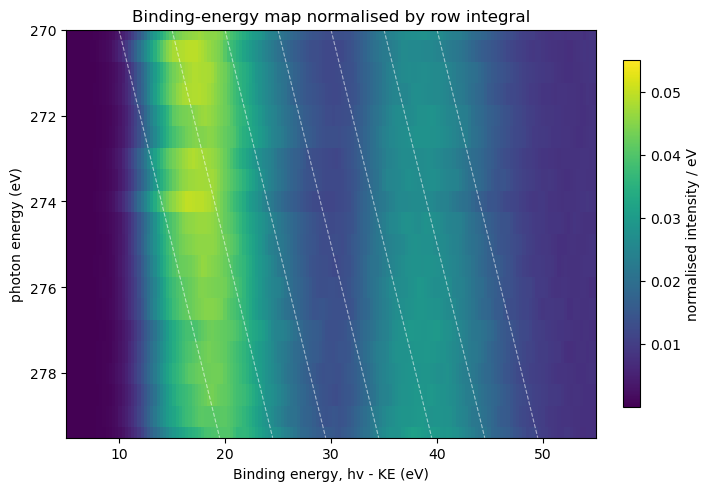

In [235]:
# --- Plot BE-normalised binding-energy map -----------------------------

vmin, vmax = _robust_limits(binding_map_norm)
vmax = 0.055

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

pcm = ax.pcolormesh(
    be_edges,
    e_edges,
    binding_map_norm,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

# Fixed-KE guide lines.
# In BE coordinates, a feature at constant KE follows:
#   BE = photon_energy - fixed_KE
fixed_ke_values = [230, 235, 240, 245, 250, 255, 260]

for fixed_ke in fixed_ke_values:
    expected_be = energies - fixed_ke

    visible = (
        np.isfinite(expected_be)
        & (expected_be >= BE_RANGE[0])
        & (expected_be <= BE_RANGE[1])
    )

    if np.any(visible):
        ax.plot(
            expected_be[visible],
            energies[visible],
            linestyle="--",
            linewidth=0.8,
            alpha=0.55,
            color="w",
        
        )

fig.colorbar(pcm, ax=ax, shrink=0.85, label="normalised intensity / eV")
ax.set_xlabel("Binding energy, hv - KE (eV)")
ax.set_ylabel("photon energy (eV)")
ax.set_title("Binding-energy map normalised by row integral")

ax.set_ylim(279.5, 270)
ax.set_xlim(BE_RANGE)



plt.show()

### For each GMD bin

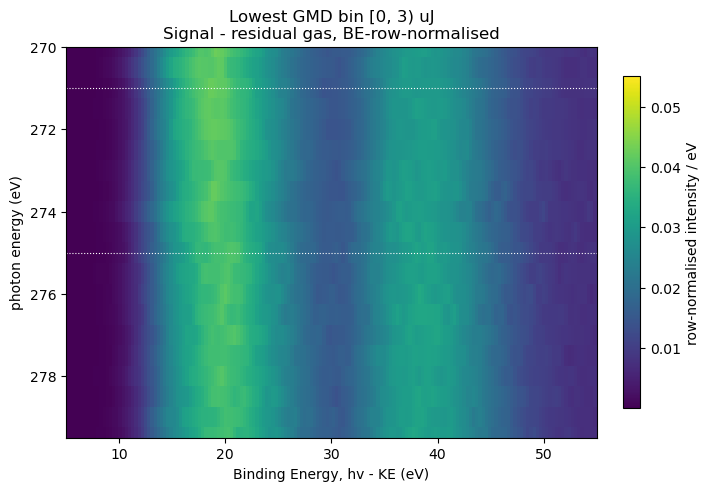

In [234]:
# --- Lowest-GMD bin: residual-background-subtracted BE map, row-normalised -----

TOF_RANGE = (800, 1100)
BE_RANGE = (5.0, 55.0)
BE_STEP = 0.3
GMD_BIN = 0

be_centres = np.arange(BE_RANGE[0], BE_RANGE[1] + BE_STEP, BE_STEP)
be_edges = _energy_edges(be_centres)
e_edges = _energy_edges(energies)


def kinetic_to_binding_map(signal_ke_map, photon_energies, ke_edges, be_centres):
    signal_ke_map = np.asarray(signal_ke_map, dtype=float)
    photon_energies = np.asarray(photon_energies, dtype=float)
    ke_centres = 0.5 * (ke_edges[:-1] + ke_edges[1:])

    be_map = np.full((len(photon_energies), len(be_centres)), np.nan)

    for row, hv in enumerate(photon_energies):
        apparent_be = hv - ke_centres
        order = np.argsort(apparent_be)

        be_map[row] = np.interp(
            be_centres,
            apparent_be[order],
            signal_ke_map[row, order],
            left=np.nan,
            right=np.nan,
        )

    return be_map


# Lowest-GMD residual-background-subtracted map.
sub_low_gmd = stack_bgsub_partial[:, GMD_BIN, :]

# Convert TOF axis to calibrated KE using your existing helper.
ke_edges, sub_low_gmd_ke = _tof_window_to_ke_edges_and_data(
    tof_edges,
    sub_low_gmd,
    TOF_RANGE,
)

# Convert KE map to apparent binding energy.
binding_low_gmd = kinetic_to_binding_map(
    signal_ke_map=sub_low_gmd_ke,
    photon_energies=energies,
    ke_edges=ke_edges,
    be_centres=be_centres,
)

# Row-normalise by integral over binding energy.
# This makes each photon-energy row have unit BE-integrated area.
be_widths = np.diff(be_edges)
binding_integral = np.nansum(binding_low_gmd * be_widths[None, :], axis=1)

with np.errstate(invalid="ignore", divide="ignore"):
    binding_low_gmd_norm = binding_low_gmd / binding_integral[:, None]

binding_low_gmd_norm[~np.isfinite(binding_low_gmd_norm)] = np.nan

# Plot.
vmin, vmax = _robust_limits(binding_low_gmd_norm)
vmax = 0.055

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

pcm = ax.pcolormesh(
    be_edges,
    e_edges,
    binding_low_gmd_norm,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, shrink=0.85, label="row-normalised intensity / eV")

ax.set_xlabel("Binding Energy, hv - KE (eV)")
ax.set_ylabel("photon energy (eV)")
ax.set_title(
    f"Lowest GMD bin [{gmd_edges[GMD_BIN]:.2g}, {gmd_edges[GMD_BIN + 1]:.2g}) uJ\n"
    "Signal - residual gas, BE-row-normalised"
)

if has_background.any():
    ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
    ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)

ax.set_ylim(279.5, 270)
ax.set_xlim(BE_RANGE)

plt.show()

## Bin size inspection and regular map (no aggregates)

In [205]:
from data_loading import load_data

# --- Runs --------------------------------------------------------------
RUN_AR = 58890   # Argon calibration
RUN_BG = 58825   # residual-gas background

# Combined-H5 paths. Default to COMBINED_DIR/run<N>.h5; override if needed.
AR_H5 = config.COMBINED_DIR / f"glycine_WL_scan_272.0eV.h5"
BG_H5 = config.COMBINED_DIR / f"background_run58890_per_energy/background_272.0eV_run58890.h5"
#BG_H5 = config.COMBINED_DIR / f"residual_gas_nozzle_in.h5"

# --- Photon energy of the Argon run (eV) -------------------------------
# REQUIRED for photoline KE = hv - BE. Read from the logbook / mpe.
PHOTON_ENERGY_EV = 270   # e.g. 285.0

# --- Signal bunch range (half-open) ------------------------------------
# Determine from the diagnostics notebook for these runs.
SIGNAL_BUNCH_RANGE = (10, 40)

# --- TOF histogram binning (ns) ----------------------------------------
# Span the eTOF window; refine after a first look at the spectrum.
TOF_MIN, TOF_MAX, TOF_BIN = 0.0, 4000.0, 1.0
tof_edges = np.arange(TOF_MIN, TOF_MAX + TOF_BIN, TOF_BIN)
tof_cent  = 0.5 * (tof_edges[:-1] + tof_edges[1:])

# --- Normalisation -----------------------------------------------------
# "per_shot": counts per (train, bunch) shot.
# "per_uJ"  : counts per shot per uJ of GMD (fluence-normalised).
NORMALISE = "per_shot"

# --- Background scaling -------------------------------------------------
# Residual-gas pressure may differ between runs; tune if the subtraction
# over/under-shoots in a known-empty TOF region.
BG_SCALE = 1.0

# --- Resolve / check ---------------------------------------------------
for label, p in [("Ar", AR_H5), ("background", BG_H5)]:
    if not Path(p).exists():
        raise FileNotFoundError(
            f"{label} combined H5 not found: {p}\n"
            f"Build it with write_h5.py (config 1) or set the path above."
        )
print(f"Ar run {RUN_AR}: {AR_H5}")
print(f"BG run {RUN_BG}: {BG_H5}")
print(f"signal bunches [{SIGNAL_BUNCH_RANGE[0]}, {SIGNAL_BUNCH_RANGE[1]}), "
      f"TOF [{TOF_MIN}, {TOF_MAX}] ns / {TOF_BIN} ns bins, normalise={NORMALISE}")

Ar run 58890: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined/glycine_WL_scan_272.0eV.h5
BG run 58825: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined/background_run58890_per_energy/background_272.0eV_run58890.h5
signal bunches [10, 40), TOF [0.0, 4000.0] ns / 1.0 ns bins, normalise=per_shot


In [206]:
b0, b1 = SIGNAL_BUNCH_RANGE

ar = load_data(str(AR_H5), config=1)
bg = load_data(str(BG_H5), config=1)

for name, d in [("Ar", ar), ("background", bg)]:
    if d.tofs_e is None:
        raise RuntimeError(f"{name} run has no tofs_e - is it a config-1 file?")
    print(f"{name:>10}: n_trains={d.n_trains}, m={d.n_bunches}, "
          f"max_ecounts={d.tofs_e.shape[-1]}")
    if not (0 <= b0 < b1 <= d.n_bunches):
        raise ValueError(
            f"{name}: SIGNAL_BUNCH_RANGE {SIGNAL_BUNCH_RANGE} outside [0, {d.n_bunches}]"
        )

        Ar: n_trains=3000, m=101, max_ecounts=50
background: n_trains=1835, m=101, max_ecounts=50


In [207]:
hits = ar.tofs_e[:, 10:40, :]
n_shots = hits.shape[0] * hits.shape[1]
n_shots
valid = hits[hits > 0] 
mask = hits > 0
valid = hits[mask]
valid

array([29716,   874,  1796, ...,  2297,  2326,  7846], dtype=uint32)

In [208]:
def average_etof(data, bunch_range, edges, normalise="per_shot"):
    """Average eTOF spectrum over a signal bunch range.

    Excludes zero-padding, histograms all hits in a single pass, and
    normalises so spectra from different runs are comparable.
    Returns (spectrum, n_shots, total_gmd).
    """
    lo, hi = bunch_range
    hits = data.tofs_e[:, lo:hi, :]            # (n_trains, n_sig, max_hits)
    n_shots = hits.shape[0] * hits.shape[1]    # number of (train, bunch) shots
    valid = hits[hits > 0]                     # drop zero-padding
    counts, _ = np.histogram(valid, bins=edges)
    counts = counts.astype(np.float64)

    gmd_sig = np.asarray(data.gmd[:, lo:hi], dtype=np.float64)
    total_gmd = np.nansum(gmd_sig)

    if normalise == "per_shot":
        spectrum = counts / max(n_shots, 1)
    elif normalise == "per_uJ":
        spectrum = counts / total_gmd if total_gmd > 0 else counts
    else:
        raise ValueError(f"unknown NORMALISE={normalise!r}")
    return spectrum, n_shots, total_gmd

ar_spec, ar_n, ar_g = average_etof(ar, SIGNAL_BUNCH_RANGE, tof_edges, NORMALISE)
bg_spec, bg_n, bg_g = average_etof(bg, SIGNAL_BUNCH_RANGE, tof_edges, NORMALISE)

print(f"Ar: {ar_n} shots, total GMD {ar_g:.3g} uJ")
print(f"BG: {bg_n} shots, total GMD {bg_g:.3g} uJ")

Ar: 90000 shots, total GMD 4.39e+05 uJ
BG: 55050 shots, total GMD 1.79e+05 uJ


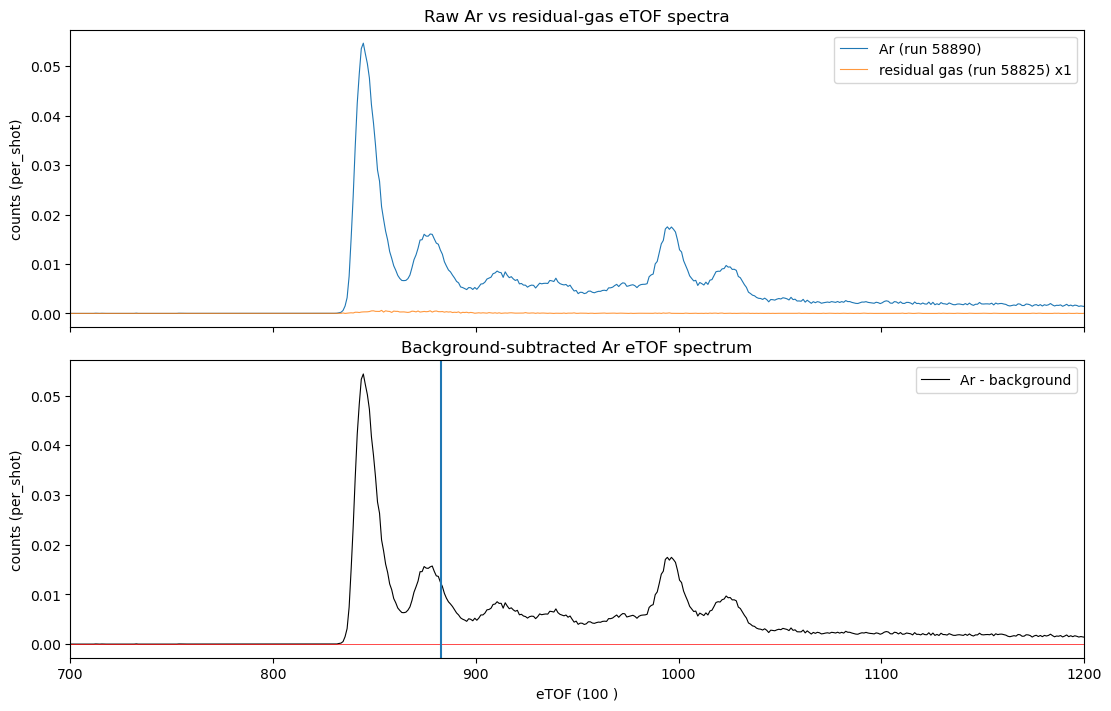

In [211]:
ar_sub = ar_spec - BG_SCALE * bg_spec

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               constrained_layout=True)
ax1.plot(tof_cent, ar_spec, lw=0.8, label=f"Ar (run {RUN_AR})")
ax1.plot(tof_cent, BG_SCALE * bg_spec, lw=0.8, alpha=0.8,
         label=f"residual gas (run {RUN_BG}) x{BG_SCALE:g}")
ax1.set_ylabel(f"counts ({NORMALISE})")
ax1.legend(); ax1.set_title("Raw Ar vs residual-gas eTOF spectra")

ax2.plot(tof_cent, ar_sub, lw=0.8, color="k", label="Ar - background")
ax2.axhline(0, color="r", lw=0.5)
ax2.set_xlabel("eTOF (100 )"); ax2.set_ylabel(f"counts ({NORMALISE})")
ax2.legend(); ax2.set_title("Background-subtracted Ar eTOF spectrum")
ax2.axvline(883)

# ax2.axvline(x=920.5, color='r', linestyle='--', label='Auger M2')
# ax2.axvline(x=1071.5, color='g', linestyle='--', label='Auger M1')
# ax2.axvline(x=850, color='b', linestyle='--', label='3p')
# ax2.axvline(x=883, color='m', linestyle='--', label='3s')

ax2.set_xlim(700, 1200)

ax2.legend()

# ax2.set_xlim(750,1200)
# ax2.set_xlim(750,1200)
plt.show()

In [178]:
# --- Diagnostic: KE width represented by one TOF bin -------------------

def tof_bin_energy_widths(tof_edges):
    """
    Return KE centre and absolute KE width for each TOF bin.

    Because KE(TOF) is nonlinear, each TOF bin maps to a different
    energy width.
    """
    tof_edges = np.asarray(tof_edges, dtype=float)

    tof_centres = 0.5 * (tof_edges[:-1] + tof_edges[1:])
    ke_edges = tof_to_ke(tof_edges)
    ke_centres = tof_to_ke(tof_centres)

    dke_per_bin = np.abs(np.diff(ke_edges))

    good = (
        np.isfinite(tof_centres)
        & np.isfinite(ke_centres)
        & np.isfinite(dke_per_bin)
    )

    return tof_centres[good], ke_centres[good], dke_per_bin[good]


tof_centres, ke_centres, dke_per_bin = tof_bin_energy_widths(tof_edges)

# Restrict to the TOF range used in your plot.
mask = np.ones_like(tof_centres, dtype=bool)

if TOF_RANGE[0] is not None:
    mask &= tof_centres >= TOF_RANGE[0]
if TOF_RANGE[1] is not None:
    mask &= tof_centres <= TOF_RANGE[1]

tof_w = tof_centres[mask]
ke_w = ke_centres[mask]
dke_w = dke_per_bin[mask]

print(f"TOF bin width in original axis: {np.nanmedian(np.diff(tof_edges)):.6g} TOF units")
print(f"TOF range inspected: {TOF_RANGE}")
print()
print("Across this TOF window:")
print(f"  KE range              : {np.nanmin(ke_w):.3f} to {np.nanmax(ke_w):.3f} eV")
print(f"  eV per TOF bin, min   : {np.nanmin(dke_w):.6f} eV")
print(f"  eV per TOF bin, median: {np.nanmedian(dke_w):.6f} eV")
print(f"  eV per TOF bin, max   : {np.nanmax(dke_w):.6f} eV")

# Value nearest TOF = 800.
target_tof = 840
i = np.nanargmin(np.abs(tof_centres - target_tof))

print()
print(f"Nearest actual TOF bin to {target_tof:g}:")
print(f"  TOF centre            : {tof_centres[i]:.3f}")
print(f"  TOF edges             : {tof_edges[i]:.3f} to {tof_edges[i + 1]:.3f}")
print(f"  KE centre             : {ke_centres[i]:.3f} eV")
print(f"  KE edges              : {tof_to_ke(tof_edges[i]):.3f} to {tof_to_ke(tof_edges[i + 1]):.3f} eV")
print(f"  abs energy width/bin  : {dke_per_bin[i]:.6f} eV")

# Optional analytic local slope at exactly TOF = 800.
# KE = best_slope / (t - best_t0)^2 + best_E0
local_ev_per_tof = abs(-2 * best_slope / (target_tof - best_t0) ** 3)

print()
print(f"Analytic local |dKE/dTOF| at TOF={target_tof:g}:")
print(f"  {local_ev_per_tof:.6f} eV per TOF unit")

TOF bin width in original axis: 1 TOF units
TOF range inspected: (800, 1100)

Across this TOF window:
  KE range              : 130.988 to 291.815 eV
  eV per TOF bin, min   : 0.316763 eV
  eV per TOF bin, median: 0.507265 eV
  eV per TOF bin, max   : 0.886987 eV

Nearest actual TOF bin to 840:
  TOF centre            : 839.500
  TOF edges             : 768.000 to 769.000
  KE centre             : 259.809 eV
  KE edges              : 322.688 to 321.673 eV
  abs energy width/bin  : 0.758793 eV

Analytic local |dKE/dTOF| at TOF=840:
  0.757315 eV per TOF unit


### Interpolating to a uniform eV grid and smoothing

In [194]:
# --- Interpolate TOF-binned map onto uniform KE bins, then smooth -------

from scipy.ndimage import uniform_filter1d

ENERGY_STEP = 0.3          # eV
SMOOTHING_WIDTH_EV = 2.5   # eV
TOF_RANGE = (800, 1100)


def _uniform_edges_from_range(xmin, xmax, step):
    lo = np.ceil(xmin / step) * step
    hi = np.floor(xmax / step) * step
    return np.arange(lo, hi + step, step)


def _nan_uniform_filter1d(a, size, axis=-1, mode="nearest"):
    """
    NaN-aware uniform filter.
    Prevents NaNs from spreading through the smoothed map.
    """
    a = np.asarray(a, dtype=float)
    valid = np.isfinite(a)

    numerator = uniform_filter1d(
        np.where(valid, a, 0.0),
        size=size,
        axis=axis,
        mode=mode,
    )

    denominator = uniform_filter1d(
        valid.astype(float),
        size=size,
        axis=axis,
        mode=mode,
    )

    with np.errstate(invalid="ignore", divide="ignore"):
        out = numerator / denominator

    out[denominator <= 0] = np.nan
    return out


def tof_map_to_uniform_ke_map(tof_edges, data, tof_range, energy_step=0.3):
    """
    Convert a TOF-binned map to a uniform KE grid by interpolation.

    This is intended for plotting/smoothing. It preserves the colour-scale
    quantity approximately, but it is not a strict counts-conserving rebin.
    """
    ke_edges_raw, data_ke_raw = _tof_window_to_ke_edges_and_data(
        tof_edges,
        data,
        tof_range,
    )

    ke_centres_raw = 0.5 * (ke_edges_raw[:-1] + ke_edges_raw[1:])

    ke_uniform_edges = _uniform_edges_from_range(
        np.nanmin(ke_centres_raw),
        np.nanmax(ke_centres_raw),
        energy_step,
    )
    ke_uniform_centres = 0.5 * (ke_uniform_edges[:-1] + ke_uniform_edges[1:])

    data_uniform = np.full(
        (data_ke_raw.shape[0], ke_uniform_centres.size),
        np.nan,
        dtype=float,
    )

    order = np.argsort(ke_centres_raw)
    x = ke_centres_raw[order]

    for i in range(data_ke_raw.shape[0]):
        y = data_ke_raw[i, order]
        good = np.isfinite(x) & np.isfinite(y)

        if good.sum() >= 2:
            data_uniform[i] = np.interp(
                ke_uniform_centres,
                x[good],
                y[good],
                left=np.nan,
                right=np.nan,
            )

    return ke_uniform_edges, ke_uniform_centres, data_uniform


# Choose which map to process.
# You can replace subtracted_total with signal_total or background_total.
ke_edges_03eV, ke_centres_03eV, subtracted_03eV = tof_map_to_uniform_ke_map(
    tof_edges=tof_edges,
    data=subtracted_total,
    tof_range=TOF_RANGE,
    energy_step=ENERGY_STEP,
)

window_bins = max(1, int(round(SMOOTHING_WIDTH_EV / ENERGY_STEP)))

subtracted_03eV_smoothed = _nan_uniform_filter1d(
    subtracted_03eV,
    size=window_bins,
    axis=1,        # smooth only along electron KE
    mode="nearest",
)

print(f"Uniform KE step: {ENERGY_STEP:.3f} eV")
print(f"Smoothing width: {SMOOTHING_WIDTH_EV:.3f} eV = {window_bins} bins")

Uniform KE step: 0.300 eV
Smoothing width: 2.500 eV = 8 bins


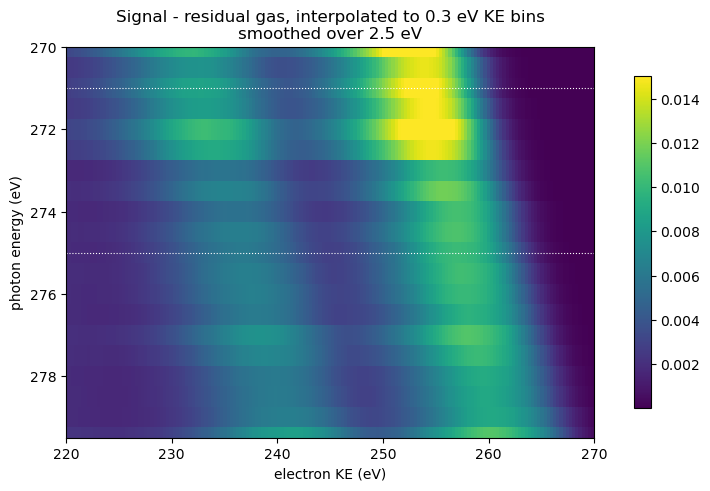

In [195]:
# --- Plot uniform-KE smoothed subtracted map ---------------------------

vmin, vmax = _robust_limits(subtracted_03eV_smoothed)
if SUB_VMAX is not None:
    vmax = SUB_VMAX

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

pcm = ax.pcolormesh(
    ke_edges_03eV,
    e_edges,
    subtracted_03eV_smoothed,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, shrink=0.85)
ax.set_xlabel("electron KE (eV)")
ax.set_ylabel("photon energy (eV)")
ax.set_title(
    f"Signal - residual gas, interpolated to {ENERGY_STEP:g} eV KE bins\n"
    f"smoothed over {SMOOTHING_WIDTH_EV:g} eV"
)

if has_background.any():
    ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
    ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)

ax.set_ylim(279.5, 270)
ax.set_xlim(220, 270)

plt.show()

## Intensity and shape scaling

The integrated intensity tracks the total residual-gas yield per GMD. The shape metric compares each spectrum to the mean background shape after area normalisation.

In [ ]:
def spectrum_area(spec, edges):
    # Spectra are histogram counts per summed GMD per bin, not densities.
    # The total yield is therefore the sum over bins.
    return np.nansum(spec, axis=1)


def shape_distance(spec, edges):
    area = spectrum_area(spec, edges)
    shape = spec / area[:, None]
    ref = np.nanmean(shape, axis=0)
    return np.sqrt(np.nansum((shape - ref) ** 2, axis=1))


e_area = spectrum_area(bg_spec_e, ETOF_BIN_EDGES)
i_area = spectrum_area(bg_spec_i, ITOF_BIN_EDGES)
e_shape_dist = shape_distance(bg_spec_e, ETOF_BIN_EDGES)
i_shape_dist = shape_distance(bg_spec_i, ITOF_BIN_EDGES)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
axes[0].plot(bg_energies, e_area, "o-", label="eTOF")
axes[0].plot(bg_energies, i_area, "o-", label="iTOF")
axes[0].set_xlabel("photon energy (eV)")
axes[0].set_ylabel("integrated hits / GMD")
axes[0].set_title("Background intensity")
axes[0].legend()

axes[1].plot(bg_energies, e_shape_dist, "o-", label="eTOF")
axes[1].plot(bg_energies, i_shape_dist, "o-", label="iTOF")
axes[1].set_xlabel("photon energy (eV)")
axes[1].set_ylabel("distance from mean shape")
axes[1].set_title("Background shape variation")
axes[1].legend()
plt.show()

## Save the per-energy background product

This creates a compact H5 file with the merged, GMD-normalised background spectra. Downstream glycine notebooks can interpolate this onto their energy axis and subtract by matching TOF bins.

In [ ]:
OUT_H5 = Path(path_config.COMBINED_DIR).parent / "xas_static" / f"run{RUN_NO}_cfg1_background_per_energy.h5"

with h5py.File(OUT_H5, "w") as f:
    f.create_dataset("energies", data=bg_energies)
    f.create_dataset("etof_edges", data=ETOF_BIN_EDGES)
    f.create_dataset("itof_edges", data=ITOF_BIN_EDGES)
    f.create_dataset("etof_background", data=bg_spec_e)
    f.create_dataset("itof_background", data=bg_spec_i)
    f.create_dataset("section_energies", data=bg["energies"])
    f.create_dataset("section_n_shots", data=bg["n_shots"])
    f.create_dataset("section_sum_gmd", data=bg_sum_gmd)
    f.attrs["source_static_xas"] = str(BACKGROUND_STATIC_H5)
    f.attrs["normalisation"] = "hits per summed GMD per TOF bin"
    f.attrs["duplicate_energy_policy"] = DUPLICATE_ENERGY_POLICY

print("wrote", OUT_H5)

## Optional glycine subtraction

Set `SIGNAL_STATIC_H5` above to a glycine static-XAS file with compatible TOF binning. This section plots the glycine signal map, the residual-gas background interpolated onto the glycine photon-energy axis, and the difference.

In [ ]:
if SIGNAL_STATIC_H5 is not None:
    sig = load_static_xas(SIGNAL_STATIC_H5)
    sig_spec_e_raw, sig_sum_gmd, _, _ = spectra_per_energy(
        sig["tofs_e"], sig["gmd"], sig["n_shots"], ETOF_BIN_EDGES
    )
    sig_spec_i_raw, _, _, _ = spectra_per_energy(
        sig["tofs_i"], sig["gmd"], sig["n_shots"], ITOF_BIN_EDGES
    )

    sig_energies, sig_spec_e = resolve_duplicate_energies(
        sig_spec_e_raw, sig["energies"], policy=DUPLICATE_ENERGY_POLICY, weights=sig_sum_gmd
    )
    _, sig_spec_i = resolve_duplicate_energies(
        sig_spec_i_raw, sig["energies"], policy=DUPLICATE_ENERGY_POLICY, weights=sig_sum_gmd
    )

    bg_on_sig_e = np.vstack([
        np.interp(sig_energies, bg_energies, bg_spec_e[:, j], left=np.nan, right=np.nan)
        for j in range(bg_spec_e.shape[1])
    ]).T
    bg_on_sig_i = np.vstack([
        np.interp(sig_energies, bg_energies, bg_spec_i[:, j], left=np.nan, right=np.nan)
        for j in range(bg_spec_i.shape[1])
    ]).T

    sub_e = sig_spec_e - BACKGROUND_SCALE * bg_on_sig_e
    sub_i = sig_spec_i - BACKGROUND_SCALE * bg_on_sig_i

    plot_map(sig_spec_e, ETOF_BIN_EDGES, sig_energies, title="Glycine eTOF signal", clabel="hits / GMD / bin", tof_range=ETOF_RANGE)
    plt.show()
    plot_map(bg_on_sig_e, ETOF_BIN_EDGES, sig_energies, title="Residual-gas eTOF background on glycine energy axis", clabel="hits / GMD / bin", tof_range=ETOF_RANGE)
    plt.show()
    plot_diff_map(sub_e, ETOF_BIN_EDGES, sig_energies, title="Glycine eTOF minus residual-gas background", clabel="subtracted hits / GMD / bin", tof_range=ETOF_RANGE)
    plt.show()

    plot_map(sig_spec_i, ITOF_BIN_EDGES, sig_energies, title="Glycine iTOF signal", clabel="hits / GMD / bin", tof_range=ITOF_RANGE)
    plt.show()
    plot_map(bg_on_sig_i, ITOF_BIN_EDGES, sig_energies, title="Residual-gas iTOF background on glycine energy axis", clabel="hits / GMD / bin", tof_range=ITOF_RANGE)
    plt.show()
    plot_diff_map(sub_i, ITOF_BIN_EDGES, sig_energies, title="Glycine iTOF minus residual-gas background", clabel="subtracted hits / GMD / bin", tof_range=ITOF_RANGE)
    plt.show()

elif SIGNAL_AGG_FILES is not None:
    sig = load_signal_aggregate_map(SIGNAL_AGG_FILES, gmd_bin=SIGNAL_GMD_BIN)
    sig_energies = sig["energies"]
    sig_spec_e = sig["spec_e"]
    sig_edges = sig["tof_edges"]

    bg_spec_for_signal = rebin_background_if_needed(bg_spec_e, ETOF_BIN_EDGES, sig_edges)
    bg_on_sig_e = np.vstack([
        np.interp(sig_energies, bg_energies, bg_spec_for_signal[:, j], left=np.nan, right=np.nan)
        for j in range(bg_spec_for_signal.shape[1])
    ]).T
    sub_e = sig_spec_e - BACKGROUND_SCALE * bg_on_sig_e

    suffix = "weighted over GMD bins" if SIGNAL_GMD_BIN is None else f"GMD bin {SIGNAL_GMD_BIN}"
    plot_map(sig_spec_e, sig_edges, sig_energies, title=f"Glycine aggregate eTOF signal ({suffix})", clabel="D / G", tof_range=ETOF_RANGE)
    plt.show()
    plot_map(bg_on_sig_e, sig_edges, sig_energies, title="Residual-gas eTOF background on glycine aggregate energy axis", clabel="hits / GMD / bin", tof_range=ETOF_RANGE)
    plt.show()
    plot_diff_map(sub_e, sig_edges, sig_energies, title="Glycine aggregate eTOF minus residual-gas background", clabel="subtracted D / G", tof_range=ETOF_RANGE)
    plt.show()

else:
    print("Set SIGNAL_STATIC_H5 or SIGNAL_AGG_FILES to enable glycine subtraction plots.")